# 1. Introduction

In the last few years, the area of computer vision has undergone substantial development. This branch of technology is dedicated to the comprehensive set of processes involved in obtaining, processing, analyzing, and comprehending digital images to extract meaningful information.

One key technique among these processes is known as image segmentation. This specific method plays a crucial role in dividing an image into parts or segments to simplify or change the representation of an image into something that is more meaningful and easier to analyze. Image segmentation is fundamental in identifying objects and boundaries (lines, curves, etc.) in images, making it a critical step in many computer vision tasks.

Image segmentation plays a pivotal role in medical imaging by enabling precise segmentation of brain tumors. This technique facilitates accurate tumor identification and boundary delineation within MRI scans, which is essential for diagnosis, treatment planning, and monitoring the progression of brain tumors. By automating and enhancing the analysis of medical images, image segmentation significantly contributes to improved patient outcomes in the field of neuro-oncology.

# Changelog — Improvements over the original notebook

This notebook is a corrected/improved version of the original PyTorch U-Net. Key changes (with rationale):

**Correctness fixes (these affect results):**
1. **Per-channel normalization** in the data pipeline. The original divided *both* input channels by a single global max, which squashed the lower-intensity T1ce channel into a fraction of [0,1] — effectively dimming the most diagnostic modality for the enhancing/necrotic classes. Now each channel is min–max normalized independently. Inference (`predictByPath`) was updated to match, fixing a train/test normalization mismatch.
2. **Nearest-neighbour mask resizing.** The original one-hot encoded at full resolution then bilinearly resized each channel, producing fractional labels and eroding small structures. Now the integer label map is resized with `INTER_NEAREST` *before* one-hot encoding, keeping labels clean and preserving small lesions.
3. **Fixed model input-channel default** (`in_channels=2`) and **corrected the crossed labels** in the prediction visualization (class 1 = NCR/CORE, class 2 = EDEMA were swapped in titles).
4. **Reproducible, patient-level split** with fixed seeds (`random_state`), so the train/val/test partition is stable across runs and no patient's slices leak between sets.

**Model / training improvements:**
5. **BatchNorm** added to every conv block — the original from-scratch U-Net had none, which slows and destabilizes training.
6. **Combined Dice + CrossEntropy loss** (`DiceCELoss`) instead of plain CrossEntropy, which is dominated by the huge background class. The Dice term directly optimizes foreground overlap — the standard choice for imbalanced medical segmentation.
7. **Checkpoint & LR-schedule on validation Dice** (maximize) rather than loss, since Dice is the metric of interest. Only the best model is saved (the original wrote one checkpoint per epoch, filling the Kaggle disk).

**Performance:**\n0. **Data preloaded into RAM once** instead of reloading three full MRI volumes from disk for every slice (a ~100x redundant-I/O reduction). This was the real training bottleneck; after this change each epoch is GPU-bound and runs in seconds on a T4.\n\n**Evaluation improvements:**
8. **BraTS nested-region Dice (WT / TC / ET)** added alongside the per-class Dice, computed from the hard prediction. These are the numbers every BraTS paper reports, so your results become directly comparable to published baselines.

*Note on metrics:* specificity stays near 0.99 regardless of model quality because background dominates every slice — Dice and sensitivity carry the real signal.

# 2. Download and Unzip the Dataset

In [1]:
! pip install kaggle

In [2]:
! mkdir ~/.kaggle

In [3]:
! cp kaggle.json ~/.kaggle/

cp: cannot stat 'kaggle.json': No such file or directory


In [4]:
! chmod 600 ~/.kaggle/kaggle.json

chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [5]:
! kaggle datasets download awsaf49/brats20-dataset-training-validation

Dataset URL: https://www.kaggle.com/datasets/awsaf49/brats20-dataset-training-validation
License(s): CC0-1.0
100%|███████████████████████████████████████| 4.16G/4.16G [00:22<00:00, 195MB/s]



In [6]:
! unzip brats20-dataset-training-validation.zip "BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_0[0-5][0-9]/*"


Archive:  brats20-dataset-training-validation.zip
  inflating: BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_flair.nii  
  inflating: BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_seg.nii  
  inflating: BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_t1.nii  
  inflating: BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_t1ce.nii  
  inflating: BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_t2.nii  
  inflating: BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_002/BraTS20_Training_002_flair.nii  
  inflating: BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_002/BraTS20_Training_002_seg.nii  
  inflating: BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_002/BraTS20_Training_002_t1.nii  
  in

# 3. Dataset Information

The Brain Tumor Segmentation (BraTS) 2020 dataset is a collection of multimodal Magnetic Resonance Imaging (MRI) scans used for the segmentation of brain tumors.

It includes MRI scans from glioma patients, providing four different MRI modalities (means 4 channels of information - 4 different volumes of the same region) per patient:
1. **Native (T1)**
2. **Post-contrast T1-weighted (T1ce - contrast enhanced)**
3. **T2-weighted (T2)**
4. **T2-FLAIR (T2 - Fluid Attenuated Inversion Recovery)**

These scans come with expert-annotated segmentation masks that delineate the tumor into various sub-regions, such as the necrotic and non-enhancing tumor core, the peritumoral edema, and the enhancing tumor.

Annotations (labels):
  1. **Label 0**: Not Tumor (NT) volume
  2. **Label 1**: Necrotic and non-enhancing tumor core (NCR/NET)
  3. **Label 2**: Peritumoral edema (ED)
  4. **Label 3**: Missing (No pixels in all the volumes contain label 3)
  5. **Label 4**: GD-enhancing tumor (ET)

As there are no pixels with the label 3, we will be replacing label 3 with label 4 so that there is continuity between the labels.

Now that we have downloaded the dataset, let's try to explore & understand it!

Inside the `brats20-dataset-training-validation` folder, you will find two datasets: one for Training and one for Validation. If you open the `BraTS2020_TrainingData` folder, you will notice that it contains another folder, that contains 369 samples (which are patients here). 

# 4. Load and Explore the Dataset

In [7]:
import os
import cv2
import glob
import time
import random
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from skimage import data
from skimage.util import montage
import skimage.transform as skTrans
from skimage.transform import rotate
from skimage.transform import resize
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

# --- Reproducibility (added) ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


In [8]:
TRAIN_DATASET_PATH = "/kaggle/working/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/"

In [9]:
# load .nii file as a numpy array

test_image_flair = nib.load(TRAIN_DATASET_PATH + "BraTS20_Training_025/BraTS20_Training_025_flair.nii").get_fdata()
print("Shape: ", test_image_flair.shape)
print("Dtype: ", test_image_flair.dtype)

Shape:  (240, 240, 155)
Dtype:  float64


In [10]:
print("Min: ", test_image_flair.min())
print("Max: ", test_image_flair.max())

Min:  0.0
Max:  711.0


As we can see the maximum pixel value of the image is `1854.6` which gives us a good idea to rescale these values. Rescaling pixel values is essential because it standardizes the intensity values across multimodal MRI scans (T1, T1ce, T2, FLAIR) to a uniform scale. This uniformity is crucial for consistent model training and analysis, as it ensures that variations in pixel intensity due to different imaging modalities and equipment do not bias the segmentation model. It facilitates the model's ability to learn meaningful features from the data for accurate tumor segmentation, regardless of the inherent differences in the raw MRI scans.

In [11]:
scaler = MinMaxScaler()

In [12]:
# Scale the test_image_flair array and then reshape it back to its original dimensions.
# This ensures the data is normalized/standardized for model input without altering its spatial structure.
test_image_flair = scaler.fit_transform(test_image_flair.reshape(-1, test_image_flair.shape[-1])).reshape(test_image_flair.shape)

In [13]:
print("Min: ", test_image_flair.min())
print("Max: ", test_image_flair.max())

Min:  0.0
Max:  1.0


In [14]:
# rescaling t1
test_image_t1 = nib.load(TRAIN_DATASET_PATH + 'BraTS20_Training_035/BraTS20_Training_035_t1.nii').get_fdata()
test_image_t1 = scaler.fit_transform(test_image_t1.reshape(-1, test_image_t1.shape[-1])).reshape(test_image_t1.shape)

# rescaling t1ce
test_image_t1ce = nib.load(TRAIN_DATASET_PATH + 'BraTS20_Training_035/BraTS20_Training_035_t1ce.nii').get_fdata()
test_image_t1ce = scaler.fit_transform(test_image_t1ce.reshape(-1, test_image_t1ce.shape[-1])).reshape(test_image_t1ce.shape)

# rescaling t2
test_image_t2 = nib.load(TRAIN_DATASET_PATH + 'BraTS20_Training_035/BraTS20_Training_035_t2.nii').get_fdata()
test_image_t2 = scaler.fit_transform(test_image_t2.reshape(-1, test_image_t2.shape[-1])).reshape(test_image_t2.shape)

# we will not rescale the mask
test_image_seg = nib.load(TRAIN_DATASET_PATH + 'BraTS20_Training_035/BraTS20_Training_035_seg.nii').get_fdata()

Slice Number: 45


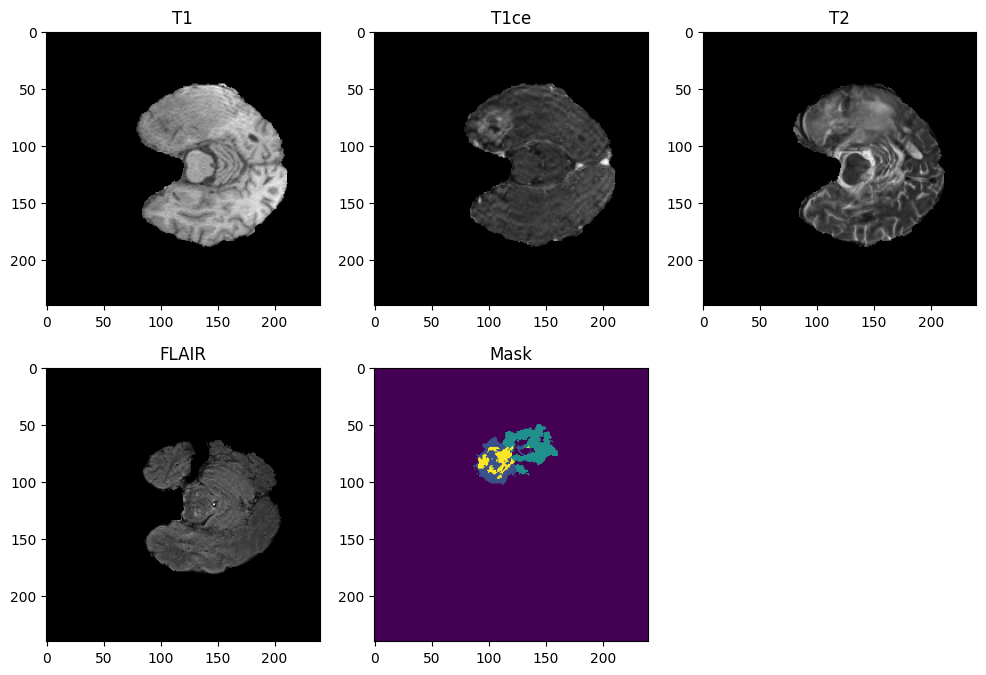

In [15]:
slice = 45

print("Slice Number: " + str(slice))

plt.figure(figsize=(12, 8))

# T1
plt.subplot(2, 3, 1)
plt.imshow(test_image_t1[:,:,slice], cmap='gray')
plt.title('T1')

# T1ce
plt.subplot(2, 3, 2)
plt.imshow(test_image_t1ce[:,:,slice], cmap='gray')
plt.title('T1ce')

# T2
plt.subplot(2, 3, 3)
plt.imshow(test_image_t2[:,:,slice], cmap='gray')
plt.title('T2')

# Flair
plt.subplot(2, 3, 4)
plt.imshow(test_image_flair[:,:,slice], cmap='gray')
plt.title('FLAIR')

# Mask
plt.subplot(2, 3, 5)
plt.imshow(test_image_seg[:,:,slice])
plt.title('Mask')
plt.show()

The four imaging modalities provide distinct perspectives on the same brain image, each highlighting different features.

**Detailed Description of Each Modality:**

1. **Native (T1):** This modality reveals the structure and composition of various tissue types in the brain. It's instrumental in identifying tumors, cysts, and other abnormalities.
2. **Post-contrast T1-weighted (T1ce, also known as T1Gd):** Similar to T1 images, but enhanced with a contrast agent (Gadolinium), which improves the visibility of abnormalities.
3. **T2-weighted (T2):** This modality highlights the fluid content within brain tissues.
4. **T2-FLAIR (T2 - Fluid Attenuated Inversion Recovery):** This technique suppresses the fluid signals, making it easier to identify lesions that may not be visible on T1 or T2 images. It is particularly useful for detecting lesions in the brain's white matter, which are challenging to spot with other scans.

For medical experts, these four modalities collectively provide a comprehensive view, aiding in precise tumor analysis and confirmation. However, in our artificial intelligence approach, we aim to streamline the process by reducing computational and memory demands. Utilizing only two modalities can achieve this, making the segmentation task faster and more efficient.

To optimize our model, we will exclude the T1 modality since its enhanced counterpart, **T1ce**, provides better clarity. Similarly, we will omit the T2 modality because the fluids it highlights could negatively impact our predictions. Instead, the **T2-FLAIR** modality, which effectively highlights affected regions by suppressing fluid signals, will be more beneficial for our training.

### Images Format

You may have noticed that these images are in the .nii format. These scans are NIfTI files (Neuroimaging Informatics Technology Initiative). A NIfTI image provides a digital representation of a 3D object, such as a brain in our case. The NIfTI format is widely used in neuroimaging because it efficiently handles complex, multi-dimensional data and includes metadata for spatial orientation and scaling.

To gain a better understanding of the data structure, let's examine the shape of a modality scan and a segmentation mask. Note that in this dataset, all modalities and their corresponding segmentation masks share the same dimensions:

In [16]:
# Modality shape
print("Modality: ", test_image_t1.shape)

# Segmentation shape
print("Segmentation: ", test_image_seg.shape)

Modality:  (240, 240, 155)
Segmentation:  (240, 240, 155)


As we can see, the modalities and segmentations have 3 dimensions. Each dimension consists of a series of two-dimensional images, known as slices, which all contain the same number of pixels and are stacked together to create this 3D representation. For instance, in our previous example, we displayed the 95th slice of a certain dimension.

These 3 dimensions correspond to the three spatial dimensions of the image: width, height, and depth. In medical imaging, these dimensions are referred to as the axial (transverse), coronal, and sagittal planes, corresponding to the three main orientations of the human body and, therefore, the human brain.

Here is a quick presentation of these 3 planes:

1. **Axial (Transverse) Plane:** This plane divides the body into upper and lower parts and is perpendicular to the long axis of the body. In brain imaging, an axial slice is a horizontal cut through the brain.
2. **Coronal (Frontal) Plane:** This plane divides the body into front (anterior) and back (posterior) parts. A coronal slice in brain imaging is a vertical cut from one side of the head to the other, dividing the brain into front and back sections.
3. **Sagittal (Lateral) Plane:** This plane divides the body into left and right parts. A sagittal slice in brain imaging is a vertical cut from front to back, dividing the brain into left and right sections.

Understanding these planes is crucial for accurately interpreting medical images and effectively utilizing them in segmentation tasks. Each plane provides a different perspective, helping to localize and identify anatomical structures and abnormalities.

Slice number: 65


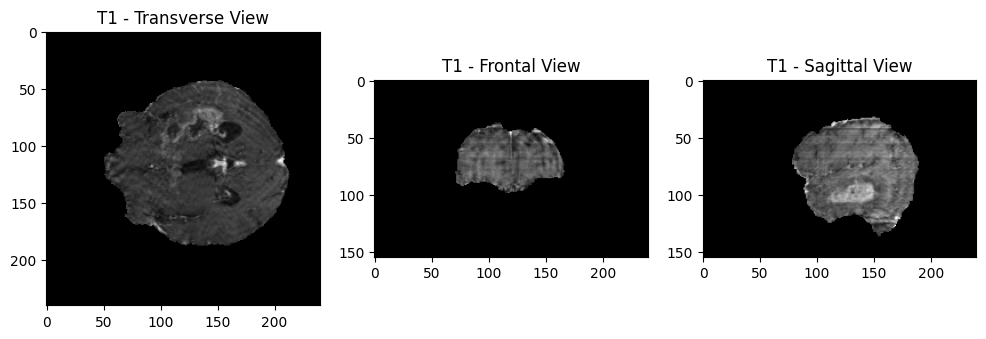

In [17]:
slice = 65

print("Slice number: " + str(slice))

plt.figure(figsize=(12, 8))

# Apply a 90° rotation with an automatic resizing, otherwise the display is less obvious to analyze
# T1 - Transverse View
plt.subplot(1, 3, 1)
plt.imshow(test_image_t1ce[:,:,slice], cmap='gray')
plt.title('T1 - Transverse View')

# T1 - Frontal View
plt.subplot(1, 3, 2)
plt.imshow(rotate(test_image_t1ce[:,slice,:], 90, resize=True), cmap='gray')
plt.title('T1 - Frontal View')

# T1 - Sagittal View
plt.subplot(1, 3, 3)
plt.imshow(rotate(test_image_t1ce[slice,:,:], 90, resize=True), cmap='gray')
plt.title('T1 - Sagittal View')
plt.show()

This visualization helps illustrate how each plane cuts through the brain and highlights different anatomical features, aiding in comprehensive analysis and segmentation.

---
Now that we understand the three dimensions, let's explore why we chose to display a specific slice, setting the slice number to 95. By examining all the slices, we can identify the slice that best represents the region of interest, such as the area where a tumor is located.

To visualize this, we will display all the slices along one dimension:

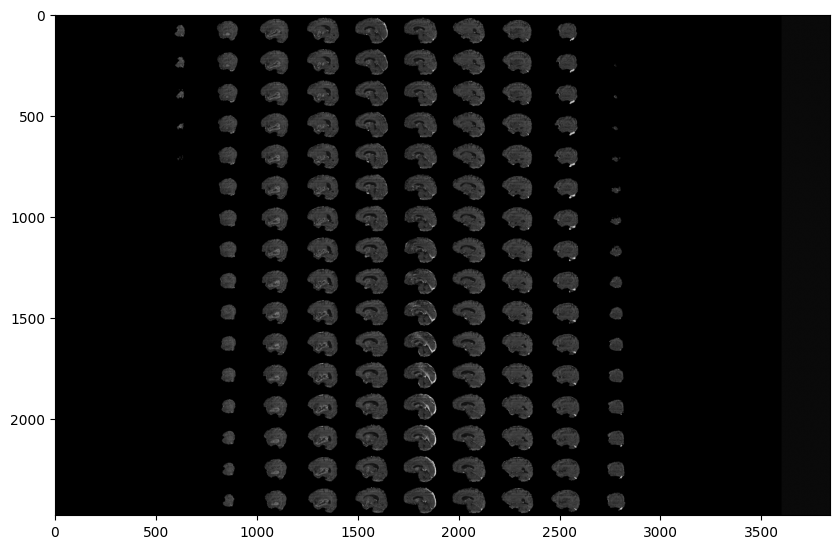

In [18]:
plt.figure(figsize=(10, 10))
plt.subplot(1, 1, 1)

# montage allows us to concatenate multiple images of the same size horizontally and vertically
plt.imshow(rotate(montage(test_image_t1ce[:,:,:]), 90, resize=True), cmap ='gray')

As you can see, two black parts are present on each side of our montage. These black parts correspond to the first and last slices of the plane. This indicates that a large portion of the slices does not contain much information, which is expected as the slices progressively represent the brain from one end to the other.

This observation is consistent across all modalities, planes, and even the expert-segmented images. The experts were unable to segment the slices that lack significant information, as these slices mostly capture areas outside the brain or the outermost regions that do not contain relevant anatomical details.

To further illustrate this, let's visualize a range of slices:

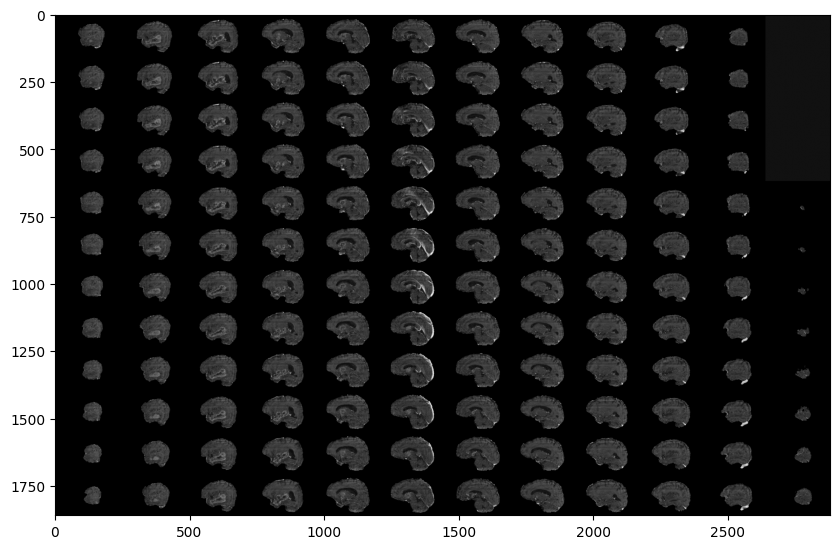

In [19]:
# Skip 50:-50 slices since there is not much to see
plt.figure(figsize=(10, 10))
plt.subplot(1, 1, 1)
plt.imshow(rotate(montage(test_image_t1ce[50:-50,:,:]), 90, resize=True), cmap ='gray')

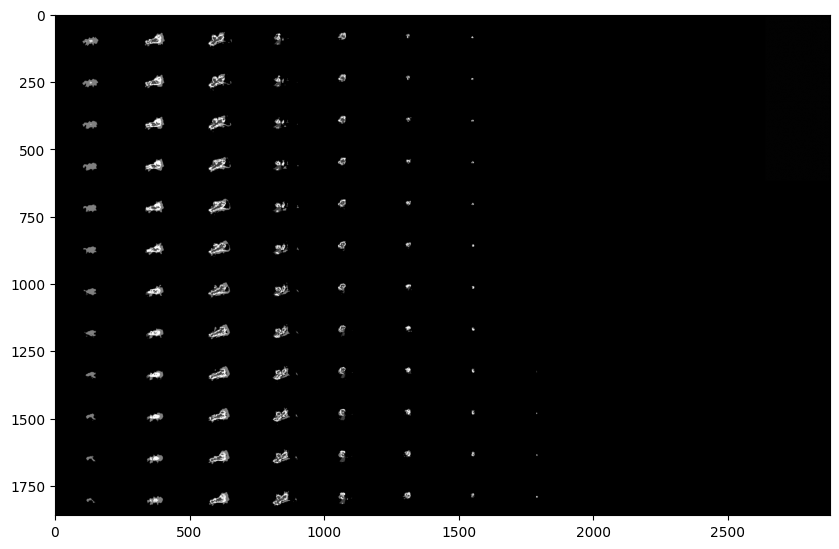

In [20]:
# Skip 50:-50 slices since there is not much to see
plt.figure(figsize=(10, 10))
plt.subplot(1, 1, 1)
plt.imshow(rotate(montage(test_image_seg[50:-50,:,:]), 90, resize=True), cmap ='gray')

By focusing on a range of slices that contain meaningful content, we can better understand the anatomical structures and the regions where abnormalities, such as tumors, may be present. This approach helps in identifying the slices that are most relevant for analysis and segmentation.

This analysis applies to all other modalities and planes as well. The segmented images by experts also reflect this pattern, as they concentrate on the slices containing significant information. Slices that do not capture much of the brain's anatomy are often left unsegmented, as they provide little to no valuable data for diagnosis or analysis.

Now, let's focus on the segmentations provided by the experts. These segmentations provide critical information about the tumor:

1. **Location:** Identifies the exact location of the tumor in the brain.
2. **Size and Shape:** Measures the tumor's dimensions and form.
3. **Type:** Helps differentiate between various tumor types.
4. **Heterogeneity:** Reveals different components within the tumor (e.g., solid tissue, necrotic areas).
5. **Surrounding Tissue Involvement:** Shows how the tumor interacts with adjacent brain structures.
6. **Cross-Modality Comparison:** Provides a comprehensive view by comparing different imaging modalities.

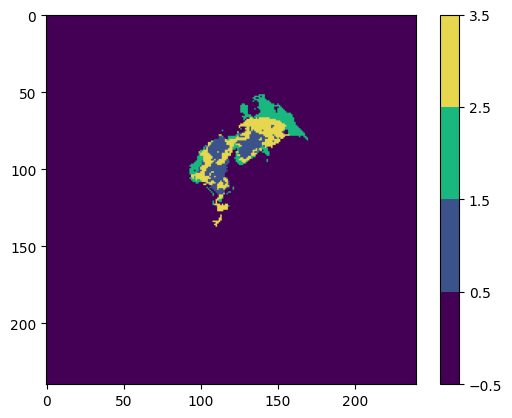

In [21]:
import matplotlib
# Plotting the segmantation
cmap = matplotlib.colors.ListedColormap(['#440054', '#3b528b', '#18b880', '#e6d74f'])
norm = matplotlib.colors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

# plotting the 95th slice
plt.imshow(test_image_seg[:,:,65], cmap=cmap, norm=norm)
plt.colorbar()
plt.show()

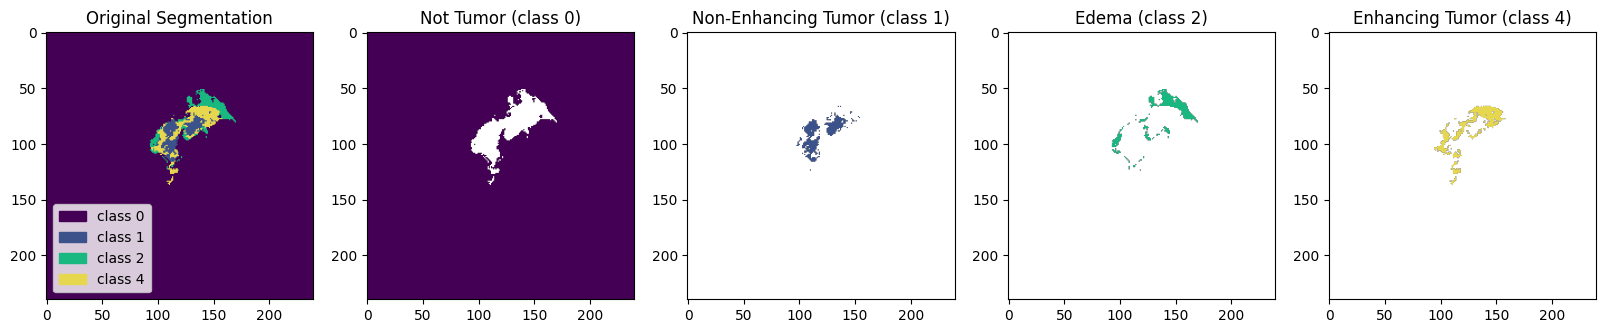

In [22]:
# Isolation of class 0
seg_0 = test_image_seg.copy()
seg_0[seg_0 != 0] = np.nan

# Isolation of class 1
seg_1 = test_image_seg.copy()
seg_1[seg_1 != 1] = np.nan

# Isolation of class 2
seg_2 = test_image_seg.copy()
seg_2[seg_2 != 2] = np.nan

# Isolation of class 4
seg_4 = test_image_seg.copy()
seg_4[seg_4 != 4] = np.nan

# Define legend
class_names = ['class 0', 'class 1', 'class 2', 'class 4']
legend = [plt.Rectangle((0, 0), 1, 1, color=cmap(i), label=class_names[i]) for i in range(len(class_names))]

fig, ax = plt.subplots(1, 5, figsize=(20, 20))

ax[0].imshow(test_image_seg[:,:, slice], cmap=cmap, norm=norm)
ax[0].set_title('Original Segmentation')
ax[0].legend(handles=legend, loc='lower left')

ax[1].imshow(seg_0[:,:, slice], cmap=cmap, norm=norm)
ax[1].set_title('Not Tumor (class 0)')

ax[2].imshow(seg_1[:,:, slice], cmap=cmap, norm=norm)
ax[2].set_title('Non-Enhancing Tumor (class 1)')

ax[3].imshow(seg_2[:,:, slice], cmap=cmap, norm=norm)
ax[3].set_title('Edema (class 2)')

ax[4].imshow(seg_4[:,:, slice], cmap=cmap, norm=norm)
ax[4].set_title('Enhancing Tumor (class 4)')

plt.show()

These insights are essential for accurate diagnosis, treatment planning, and monitoring. The segmentations help visualize the tumor clearly, making it easier to understand its characteristics and interactions with surrounding tissues.

---

To summarize our data exploration:

- **Modalities:** Each sample/patient has 4 different modalities (T1, T1CE, T2, and FLAIR), accompanied by a segmentation indicating tumor areas.
- **Selected Modalities:** We will focus on T1CE and FLAIR as they provide complementary information about the brain's anatomy and tissue contrast.
- **3D Images:** Each image is 3D and can be analyzed through 3 different planes composed of 2D slices.
- **Informative Slices:** Many slices contain little or no information. We will use slices in the (50:-50) interval. You can customize this range, but note that changing it may affect training time.
- **Segmentation Classes:** Segmentation images contain 1 to 4 classes. Class 4 will be reassigned to 3 since class 3 is missing.
- **Background Class:** Class 0 (background) is over-represented. Cropping might remove important information, so we will keep the images as they are.

Now that we understand our data better, it's time to prepare for model training.

# 5. Split the Dataset

To train and evaluate our model effectively, we need to split our dataset into three parts: the training set (70-80%) for training the model, the validation set (10-15%) for tuning hyperparameters and preventing overfitting, and the test set (10-15%) for evaluating the final model's performance. We can use random splitting to divide the data or stratified splitting to maintain the same class distribution across sets, which is particularly useful for imbalanced datasets. Properly splitting the dataset ensures that our model is robust and performs well on unseen data.

In [23]:
# lists of directories with studies
# sorted() guarantees a deterministic ordering BEFORE the split, identical to
# Task 1, so both tasks use the SAME 39/12/8 patients (no slice-level leakage).
train_and_val_directories = sorted(
    [f.path for f in os.scandir(TRAIN_DATASET_PATH) if f.is_dir()]
)

def pathListIntoIds(dirList):
    x = []
    for i in range(0, len(dirList)):
        x.append(dirList[i][dirList[i].rfind('/') + 1:])
    return x

train_and_test_ids = pathListIntoIds(train_and_val_directories)

# Fixed random_state so the split is reproducible. The split is on whole
# PATIENTS (case IDs), BEFORE slicing, so no slices leak across train/val/test.
train_test_ids, val_ids = train_test_split(train_and_test_ids, test_size=0.2, random_state=SEED)
train_ids, test_ids = train_test_split(train_test_ids, test_size=0.15, random_state=SEED)

# --- Split verification (should match Task 1) ---
import hashlib
def _fingerprint(ids):
    return hashlib.md5(','.join(sorted(ids)).encode()).hexdigest()[:10]
print(f"Train length: {len(train_ids)}")
print(f"Validation length: {len(val_ids)}")
print(f"Test length: {len(test_ids)}")
print("--- SPLIT FINGERPRINT (must match Task 1) ---")
print(f"train: {_fingerprint(train_ids)}   (expect 7dc9f2a3ec)")
print(f"val  : {_fingerprint(val_ids)}   (expect 01620d43a6)")
print(f"test : {_fingerprint(test_ids)}   (expect 90bcd58530)")
print(f"test IDs: {sorted(test_ids)}")


Train length: 39
Validation length: 12
Test length: 8
--- SPLIT FINGERPRINT (must match Task 1) ---
train: 7dc9f2a3ec   (expect 7dc9f2a3ec)
val  : 01620d43a6   (expect 01620d43a6)
test : 90bcd58530   (expect 90bcd58530)
test IDs: ['BraTS20_Training_011', 'BraTS20_Training_015', 'BraTS20_Training_016', 'BraTS20_Training_030', 'BraTS20_Training_041', 'BraTS20_Training_044', 'BraTS20_Training_057', 'BraTS20_Training_059']


In [24]:
# Print data distribution (Train: 68%, Test: 12%, Val: 20%)
print(f"Train length: {len(train_ids)}")
print(f"Validation length: {len(val_ids)}")
print(f"Test length: {len(test_ids)}")

Train length: 39
Validation length: 12
Test length: 8


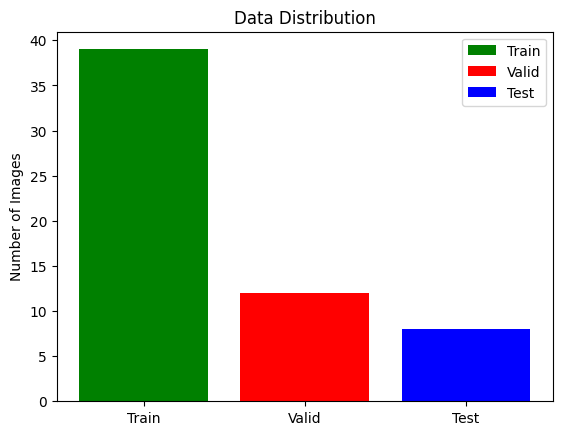

In [25]:
plt.bar(["Train","Valid","Test"],
        [len(train_ids), len(val_ids), len(test_ids)],
        align='center',
        color=[ 'green','red', 'blue'],
        label=["Train", "Valid", "Test"]
       )

plt.legend()

plt.ylabel('Number of Images')
plt.title('Data Distribution')

plt.show()

# 6. DataGenerator


To train a neural network for image segmentation, we need both raw image data (X) and ground truth segmentations (y). This allows the network to learn tumor patterns and make accurate predictions from patient scans. However, directly loading all 3D images can overload system memory and cause shape mismatch errors. Therefore, we use a Data Generator for image preprocessing, which includes several steps:

1. **Retrieve paths:** Obtain the paths for the T1CE and FLAIR modalities (for complementary anatomical and tissue contrast information) and the ground truth segmentation.
2. **Load data:** Load the selected slices (60-135) from these modalities and the corresponding segmentation.
3. **Create arrays:** Form X arrays with the slices from T1CE and FLAIR, and y arrays with the segmentation slices.
4. **Class reassignment:** Assign a value of 3 to all instances of 4 in the mask array to correct the missing class issue.

Additional preprocessing steps include:

- **Axial plane:** Use the axial plane for its square shape (240x240). This enables visualizing predictions across all planes without impact.
- **One-Hot Encoding:** Apply One-Hot Encoding to the y array to convert classes (0 to 3) into a numerical format suitable for neural networks, avoiding any implied hierarchy between classes. Here is what it consists of, for one slice:
   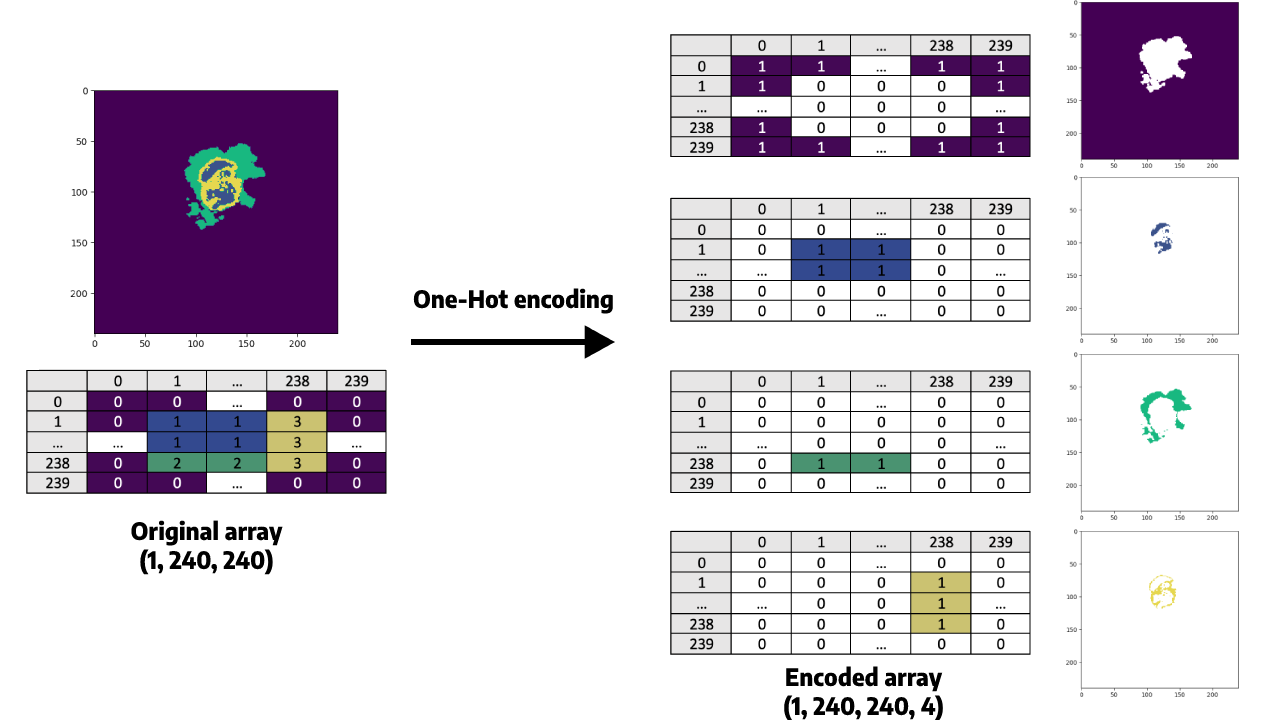
<br>
- **Resize images:** Resize each slice from (240x240) to (128x128). This shape is chosen because it is a power of two, fitting well with pooling layers (MaxPooling2D) in CNNs, and balances computational efficiency and information preservation.

While resizing to (256x256) could retain more detail, it significantly increases training time and memory usage. We can choose to train with (256x256) images, but we’ll need to adjust your U-Net architecture accordingly.

Now that we have a clear understanding of our data and preprocessing steps, we can proceed to prepare our model for training.

In [26]:
# Define seg-areas
SEGMENT_CLASSES = {
    0 : 'NOT tumor',
    1 : 'NECROTIC/CORE', # or NON-ENHANCING tumor CORE
    2 : 'EDEMA',
    3 : 'ENHANCING' # original 4 -> converted into 3
}

# Select Slices and Image Size
VOLUME_SLICES = 100
VOLUME_START_AT = 22 # first slice of volume that we will include
IMG_SIZE=128

In [27]:
TRAIN_DATASET_PATH = "/kaggle/working/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/"

# ---------------------------------------------------------------------------
# SPEED FIX: preload every case ONCE into RAM, then serve slices from memory.
#
# The naive generator reloads three full MRI volumes from disk for EVERY slice
# (100x redundant disk reads per case, every epoch) -- that disk I/O, not the
# GPU, was the bottleneck. Here we read each volume once, extract + resize +
# normalize its slices, and cache them. Training then becomes GPU-bound and
# each epoch runs in seconds on a T4.
#
# Correctness fixes are preserved:
#   * per-channel min-max normalization (FLAIR and T1ce scaled independently)
#   * nearest-neighbour mask resize BEFORE one-hot (keeps labels integer,
#     preserves small lesions)
# ---------------------------------------------------------------------------
def preload_cases(list_IDs, desc=""):
    """Load each case once; return X (N,2,H,W) float32 and Y (N,H,W) uint8 labels."""
    X_all, Y_all = [], []
    for k, case_id in enumerate(list_IDs):
        cp = os.path.join(TRAIN_DATASET_PATH, case_id)
        flair = nib.load(os.path.join(cp, f'{case_id}_flair.nii')).get_fdata()
        t1ce  = nib.load(os.path.join(cp, f'{case_id}_t1ce.nii')).get_fdata()
        seg   = nib.load(os.path.join(cp, f'{case_id}_seg.nii')).get_fdata()

        for j in range(VOLUME_SLICES):
            sp = j + VOLUME_START_AT

            x = np.zeros((IMG_SIZE, IMG_SIZE, 2), dtype=np.float32)
            x[:, :, 0] = cv2.resize(flair[:, :, sp], (IMG_SIZE, IMG_SIZE))
            x[:, :, 1] = cv2.resize(t1ce[:, :, sp],  (IMG_SIZE, IMG_SIZE))

            # per-channel normalization to [0, 1]
            for c in range(2):
                ch = x[:, :, c]
                mn, mx = ch.min(), ch.max()
                if mx > mn:
                    x[:, :, c] = (ch - mn) / (mx - mn)

            ys = seg[:, :, sp].copy()
            ys[ys == 4] = 3  # remap label 4 (ET) -> 3
            ys = cv2.resize(ys.astype(np.uint8), (IMG_SIZE, IMG_SIZE),
                            interpolation=cv2.INTER_NEAREST)  # nearest-neighbour

            X_all.append(x.transpose(2, 0, 1))  # (2, H, W)
            Y_all.append(ys)                    # (H, W) integer labels

        print(f"  {desc}: {k + 1}/{len(list_IDs)} cases loaded", end="\r")
    print()
    return np.stack(X_all), np.stack(Y_all)


class BrainDataset(Dataset):
    """Serves preloaded in-RAM slices. One-hot is built on the fly (cheap)."""
    def __init__(self, X, Y):
        self.X = X  # (N, 2, H, W) float32
        self.Y = Y  # (N, H, W)    uint8 labels

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.X[idx])  # (2, H, W)
        y = torch.from_numpy(
            np.eye(4, dtype=np.float32)[self.Y[idx]]
        ).permute(2, 0, 1)                 # (4, H, W)
        return x, y


print("Preloading data into RAM (one-time, a few minutes)...")
Xtr, Ytr = preload_cases(train_ids, "train")
Xva, Yva = preload_cases(val_ids,   "val")
Xte, Yte = preload_cases(test_ids,  "test")
print(f"Train slices: {len(Xtr)} | Val: {len(Xva)} | Test: {len(Xte)}")
print(f"Approx RAM used by cached arrays: "
      f"{(Xtr.nbytes + Xva.nbytes + Xte.nbytes) / 1e9:.2f} GB")

train_dataset = BrainDataset(Xtr, Ytr)
valid_dataset = BrainDataset(Xva, Yva)
test_dataset  = BrainDataset(Xte, Yte)

# Data already in RAM -> num_workers=0 is fastest (extra workers only add overhead).
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=0, pin_memory=True)


Preloading data into RAM (one-time, a few minutes)...
  train: 39/39 cases loaded
  val: 12/12 cases loaded
  test: 8/8 cases loaded
Train slices: 3900 | Val: 1200 | Test: 800
Approx RAM used by cached arrays: 0.77 GB


### Preprocessing Steps Summary

- **Data Generator:** Utilized to process and send data to the neural network without overloading memory.
- **Epoch Handling:** For each epoch, the model processes 250 samples from the training dataset.
- **Sample Analysis:** Each sample consists of 150 slices (100 slices each from two modalities) resized to (128, 128).
- **Data Shapes:**
  - **X Array:** Shape (128, 128, 100, 2) for input images.
  - **Ground Truth (y):** One-Hot encoded segmentation with shape (100, 128, 128, 4).

This preprocessing setup ensures efficient data handling and preparation for training the neural network.

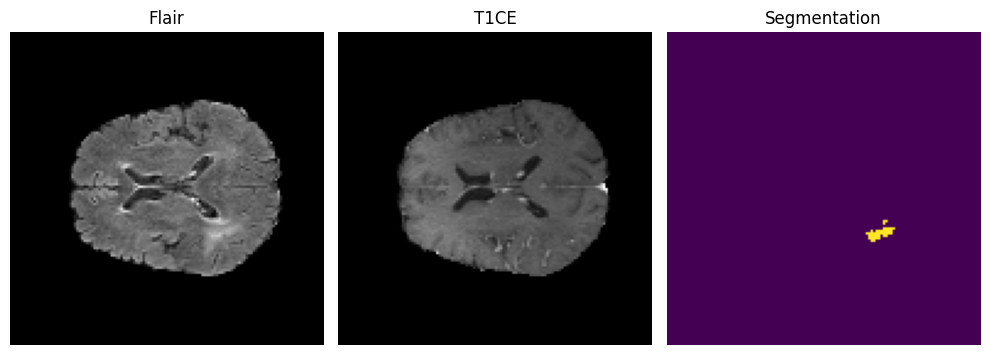

Batch shapes - X: torch.Size([32, 2, 128, 128]), Y: torch.Size([32, 4, 128, 128])


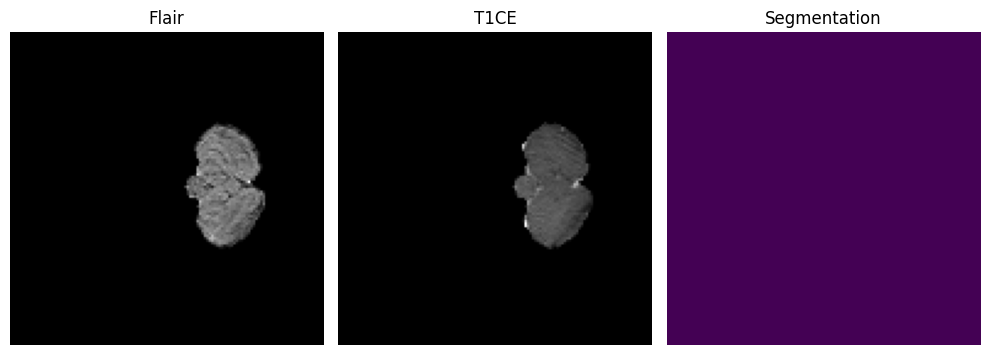

In [28]:
# Define a function to display one slice and its segmentation
def display_slice_and_segmentation(flair, t1ce, segmentation):
    fig, axes = plt.subplots(1, 3, figsize=(10, 5))

    axes[0].imshow(flair, cmap='gray')
    axes[0].set_title('Flair')
    axes[0].axis('off')

    axes[1].imshow(t1ce, cmap='gray')
    axes[1].set_title('T1CE')
    axes[1].axis('off')

    axes[2].imshow(segmentation) # Displaying segmentation
    axes[2].set_title('Segmentation')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()


# Method 1: Using individual slice dataset (BrainDataset)
# Get a specific sample directly from the dataset
sample_index = 60  # Choose your desired sample
X_sample, Y_sample = train_dataset[sample_index]

X_numpy = X_sample.permute(1, 2, 0).numpy()  # (IMG_SIZE, IMG_SIZE, 2)
Y_numpy = Y_sample.permute(1, 2, 0).numpy()  # (IMG_SIZE, IMG_SIZE, 4)

# Extract Flair and T1CE channels
slice_flair = X_numpy[:, :, 0]
slice_t1ce = X_numpy[:, :, 1]

# Convert one-hot encoded segmentation to categorical
slice_segmentation = np.argmax(Y_numpy, axis=-1)

# Display the slice and its segmentation
display_slice_and_segmentation(slice_flair, slice_t1ce, slice_segmentation)


# Method 2: Using DataLoader to get a batch
# Create a DataLoader for getting batches
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False, num_workers=0)

# Get the first batch
data_iter = iter(train_loader)
X_batch, Y_batch = next(data_iter)

print(f"Batch shapes - X: {X_batch.shape}, Y: {Y_batch.shape}")
# X_batch shape: (batch_size, 2, IMG_SIZE, IMG_SIZE)
# Y_batch shape: (batch_size, 4, IMG_SIZE, IMG_SIZE)

# Extract a specific sample from the batch (e.g., the first one)
sample_idx_in_batch = 0
X_sample_from_batch = X_batch[sample_idx_in_batch]  # (2, IMG_SIZE, IMG_SIZE)
Y_sample_from_batch = Y_batch[sample_idx_in_batch]  # (4, IMG_SIZE, IMG_SIZE)

# Convert to numpy and rearrange dimensions
X_numpy_batch = X_sample_from_batch.permute(1, 2, 0).numpy()  # (IMG_SIZE, IMG_SIZE, 2)
Y_numpy_batch = Y_sample_from_batch.permute(1, 2, 0).numpy()  # (IMG_SIZE, IMG_SIZE, 4)

# Extract channels
slice_flair_batch = X_numpy_batch[:, :, 0]
slice_t1ce_batch = X_numpy_batch[:, :, 1]
slice_segmentation_batch = np.argmax(Y_numpy_batch, axis=-1)

# Display
display_slice_and_segmentation(slice_flair_batch, slice_t1ce_batch, slice_segmentation_batch)

# 7. Loss Function and Evaluation Metrics

### Loss Function

When training a CNN, selecting an appropriate loss function is crucial for accurately reflecting the network's performance. This function compares the predicted pixels to the ground truth for each patient, guiding the model to update its weights to minimize the loss and improve prediction accuracy.

For multi-class classification problems, a commonly used loss function is **categorical cross-entropy**. This function measures the difference between the predicted probability distribution of each pixel and the one-hot encoded ground truth values. Additionally, segmentation models sometimes use the **Dice loss function**, which focuses on the overlap between the predicted and actual segments, further refining the accuracy of the segmentation.

Using these loss functions helps ensure that the model learns effectively and produces accurate segmentations of brain tumors.

In [29]:
# Dice loss as defined above for 4 classes
def dice_coef(y_true, y_pred, smooth=1.0):
    """
    Calculate Dice coefficient for multi-class segmentation
    
    Args:
        y_true: Ground truth tensor of shape (batch_size, num_classes, height, width)
        y_pred: Predicted tensor of shape (batch_size, num_classes, height, width)
        smooth: Smoothing factor to avoid division by zero
    
    Returns:
        Average Dice coefficient across all classes
    """
    class_num = 4
    total_loss = 0.0
    
    for i in range(class_num):
        y_true_f = torch.flatten(y_true[:, i, :, :])
        y_pred_f = torch.flatten(y_pred[:, i, :, :])
        intersection = torch.sum(y_true_f * y_pred_f)
        loss = (2.0 * intersection + smooth) / (torch.sum(y_true_f) + torch.sum(y_pred_f) + smooth)
        total_loss += loss
    
    return total_loss / class_num


# ---------------------------------------------------------------------------
# Combined loss: CrossEntropy + (1 - mean soft Dice).
# Rationale: pure CrossEntropy is dominated by the huge background class and
# under-weights the tiny tumor sub-regions. Adding a soft-Dice term directly
# optimizes overlap on the foreground classes and is the standard choice for
# imbalanced medical segmentation. We exclude background (class 0) from the
# Dice term so the loss focuses on tumor sub-regions.
# ---------------------------------------------------------------------------
class DiceCELoss(nn.Module):
    def __init__(self, ce_weight=0.5, dice_weight=0.5, smooth=1.0, include_background=False):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight
        self.smooth = smooth
        self.include_background = include_background

    def forward(self, logits, y_true_onehot):
        # logits: (B, C, H, W) raw; y_true_onehot: (B, C, H, W)
        target_idx = torch.argmax(y_true_onehot, dim=1)
        ce_loss = self.ce(logits, target_idx)

        probs = torch.softmax(logits, dim=1)
        start_c = 0 if self.include_background else 1
        dice_total, n = 0.0, 0
        for c in range(start_c, probs.shape[1]):
            p = probs[:, c].reshape(-1)
            t = y_true_onehot[:, c].reshape(-1)
            inter = (p * t).sum()
            dice_c = (2 * inter + self.smooth) / (p.sum() + t.sum() + self.smooth)
            dice_total += (1 - dice_c)
            n += 1
        dice_loss = dice_total / max(n, 1)
        return self.ce_weight * ce_loss + self.dice_weight * dice_loss


### Per Class Dice Coefficient Functions

These functions calculate the Dice coefficient for specific tumor classes in segmentation tasks, helping to measure the model's performance in predicting different tumor regions:

- **dice_coef_necrotic:** Calculates the Dice coefficient for the necrotic (dead tissue) tumor region. It computes the intersection over the sum of squares of the true and predicted values for the necrotic class.
  
- **dice_coef_edema:** Calculates the Dice coefficient for the edema (swelling) tumor region. It computes the intersection over the sum of squares of the true and predicted values for the edema class.
  
- **dice_coef_enhancing:** Calculates the Dice coefficient for the enhancing tumor region. It computes the intersection over the sum of squares of the true and predicted values for the enhancing class.

In [30]:

# Define per class evaluation of dice coefficient
def dice_coef_necrotic(y_true, y_pred, epsilon=1e-6):
    """
    Calculate Dice coefficient for necrotic class (class 1)
    """
    intersection = torch.sum(torch.abs(y_true[:, 1, :, :] * y_pred[:, 1, :, :]))
    return (2.0 * intersection) / (torch.sum(torch.square(y_true[:, 1, :, :])) + 
                                  torch.sum(torch.square(y_pred[:, 1, :, :])) + epsilon)

def dice_coef_edema(y_true, y_pred, epsilon=1e-6):
    """
    Calculate Dice coefficient for edema class (class 2)
    """
    intersection = torch.sum(torch.abs(y_true[:, 2, :, :] * y_pred[:, 2, :, :]))
    return (2.0 * intersection) / (torch.sum(torch.square(y_true[:, 2, :, :])) + 
                                  torch.sum(torch.square(y_pred[:, 2, :, :])) + epsilon)

def dice_coef_enhancing(y_true, y_pred, epsilon=1e-6):
    """
    Calculate Dice coefficient for enhancing class (class 3)
    """
    intersection = torch.sum(torch.abs(y_true[:, 3, :, :] * y_pred[:, 3, :, :]))
    return (2.0 * intersection) / (torch.sum(torch.square(y_true[:, 3, :, :])) + 
                                  torch.sum(torch.square(y_pred[:, 3, :, :])) + epsilon)


# ---------------------------------------------------------------------------
# BraTS clinical convention: report Dice on NESTED regions, computed from the
# hard (argmax) prediction. Labels after remap: 1=NCR/NET, 2=ED, 3=ET.
#   Whole Tumor (WT)  = {1, 2, 3}
#   Tumor Core (TC)   = {1, 3}
#   Enhancing (ET)    = {3}
# These make the numbers comparable to published BraTS baselines.
# ---------------------------------------------------------------------------
def _region_dice(pred_idx, true_idx, region_labels, eps=1e-6):
    pred_mask = torch.zeros_like(pred_idx, dtype=torch.float32)
    true_mask = torch.zeros_like(true_idx, dtype=torch.float32)
    for lbl in region_labels:
        pred_mask += (pred_idx == lbl).float()
        true_mask += (true_idx == lbl).float()
    pred_mask = (pred_mask > 0).float()
    true_mask = (true_mask > 0).float()
    inter = (pred_mask * true_mask).sum()
    denom = pred_mask.sum() + true_mask.sum()
    if denom == 0:
        return torch.tensor(1.0)  # both empty -> perfect agreement
    return (2 * inter + eps) / (denom + eps)

def dice_whole_tumor(y_true, y_pred):
    p = torch.argmax(y_pred, dim=1); t = torch.argmax(y_true, dim=1)
    return _region_dice(p, t, [1, 2, 3])

def dice_tumor_core(y_true, y_pred):
    p = torch.argmax(y_pred, dim=1); t = torch.argmax(y_true, dim=1)
    return _region_dice(p, t, [1, 3])

def dice_enhancing_region(y_true, y_pred):
    p = torch.argmax(y_pred, dim=1); t = torch.argmax(y_true, dim=1)
    return _region_dice(p, t, [3])


Each function includes a small constant (`epsilon`) to avoid division by zero.

### Evaluation Metrics

To effectively monitor the model's performance, we use various evaluation metrics:

- **Accuracy:** Measures the overall proportion of correctly classified pixels. However, it can be misleading with imbalanced datasets like BraTS2020, where the background class is overrepresented.
- **Intersection over Union (IoU):** Measures the overlap between the predicted and ground truth segmentations.
- **Dice Coefficient:** Evaluates the similarity between predicted and ground truth segmentations.
- **Sensitivity (Recall or True Positive Rate):** Measures the proportion of positive ground truth pixels correctly predicted as positive.
- **Precision (Positive Predictive Value):** Measures the proportion of predicted positive pixels that are actually positive.
- **Specificity (True Negative Rate):** Measures the proportion of negative ground truth pixels correctly predicted as negative.

Using these metrics provides a comprehensive assessment of the model’s performance, addressing the limitations of using accuracy alone on imbalanced datasets.

In [31]:
# Computing Precision
def precision(y_true, y_pred, epsilon=1e-7):
    """
    Calculate precision across all classes
    """
    true_positives = torch.sum(torch.round(torch.clamp(y_true * y_pred, 0, 1)))
    predicted_positives = torch.sum(torch.round(torch.clamp(y_pred, 0, 1)))
    precision_val = true_positives / (predicted_positives + epsilon)
    return precision_val

# Computing Sensitivity (Recall)
def sensitivity(y_true, y_pred, epsilon=1e-7):
    """
    Calculate sensitivity (recall) across all classes
    """
    true_positives = torch.sum(torch.round(torch.clamp(y_true * y_pred, 0, 1)))
    possible_positives = torch.sum(torch.round(torch.clamp(y_true, 0, 1)))
    return true_positives / (possible_positives + epsilon)

# Computing Specificity
def specificity(y_true, y_pred, epsilon=1e-7):
    """
    Calculate specificity across all classes
    """
    true_negatives = torch.sum(torch.round(torch.clamp((1 - y_true) * (1 - y_pred), 0, 1)))
    possible_negatives = torch.sum(torch.round(torch.clamp(1 - y_true, 0, 1)))
    return true_negatives / (possible_negatives + epsilon)

# 7. Define the Segmentation Model



### U-Net

We will use the U-Net architecture, a convolutional neural network (CNN) specifically designed for biomedical image segmentation. U-Net is particularly effective for segmenting regions of interest that are small and have complex shapes, such as tumors in MRI scans. This architecture was introduced in 2015 by Olaf Ronneberger, Philipp Fischer, and Thomas Brox in their paper [U-Net: Convolutional Networks for Biomedical Image Segmentation](https://arxiv.org/abs/1505.04597).

Since the BraTS2020 dataset consists of 3D images, with each image comprising multiple 2D slices in three orthogonal planes, we have two options: using a 2D U-Net or a 3D U-Net.

- **3D U-Net:** More suitable for leveraging the 3D spatial context of the images, reducing the risk of false positives and false negatives from partial information in individual slices. However, it requires more computational resources and memory.
- **2D U-Net:** Faster and requires less memory, advantageous when working with large datasets or limited computational resources.

In practice, it’s useful to try both architectures and compare their performance. We will opt for a 2D U-Net implementation due to its efficiency and lower resource requirements.

In [32]:

class UNet(nn.Module):
    """2D U-Net with BatchNorm. Outputs raw logits of shape (B, num_classes, H, W)."""
    def __init__(self, in_channels=2, num_classes=4, dropout=0.5):
        super(UNet, self).__init__()

        def CBR(cin, cout):
            # Conv -> BatchNorm -> ReLU. BatchNorm (added) stabilizes training
            # and lets us use a higher learning rate; it was absent in the
            # original, which is a notable omission for a from-scratch U-Net.
            return nn.Sequential(
                nn.Conv2d(cin, cout, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(cout),
                nn.ReLU(inplace=True),
                nn.Conv2d(cout, cout, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(cout),
                nn.ReLU(inplace=True),
            )

        # Encoder
        self.enc1 = CBR(in_channels, 32)
        self.enc2 = CBR(32, 64)
        self.enc3 = CBR(64, 128)
        self.enc4 = CBR(128, 256)
        self.pool = nn.MaxPool2d(2, 2)

        # Bottleneck
        self.bottleneck = CBR(256, 512)
        self.dropout = nn.Dropout2d(p=dropout)

        # Decoder
        self.up6 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec6 = CBR(512, 256)
        self.up7 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec7 = CBR(256, 128)
        self.up8 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec8 = CBR(128, 64)
        self.up9 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec9 = CBR(64, 32)

        self.out_conv = nn.Conv2d(32, num_classes, kernel_size=1)

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        c1 = self.enc1(x)
        c2 = self.enc2(self.pool(c1))
        c3 = self.enc3(self.pool(c2))
        c4 = self.enc4(self.pool(c3))

        bn = self.bottleneck(self.pool(c4))
        bn = self.dropout(bn)

        u6 = self.up6(bn);  d6 = self.dec6(torch.cat([c4, u6], dim=1))
        u7 = self.up7(d6);  d7 = self.dec7(torch.cat([c3, u7], dim=1))
        u8 = self.up8(d7);  d8 = self.dec8(torch.cat([c2, u8], dim=1))
        u9 = self.up9(d8);  d9 = self.dec9(torch.cat([c1, u9], dim=1))

        return self.out_conv(d9)  # raw logits


Here is the visual representation of our model:

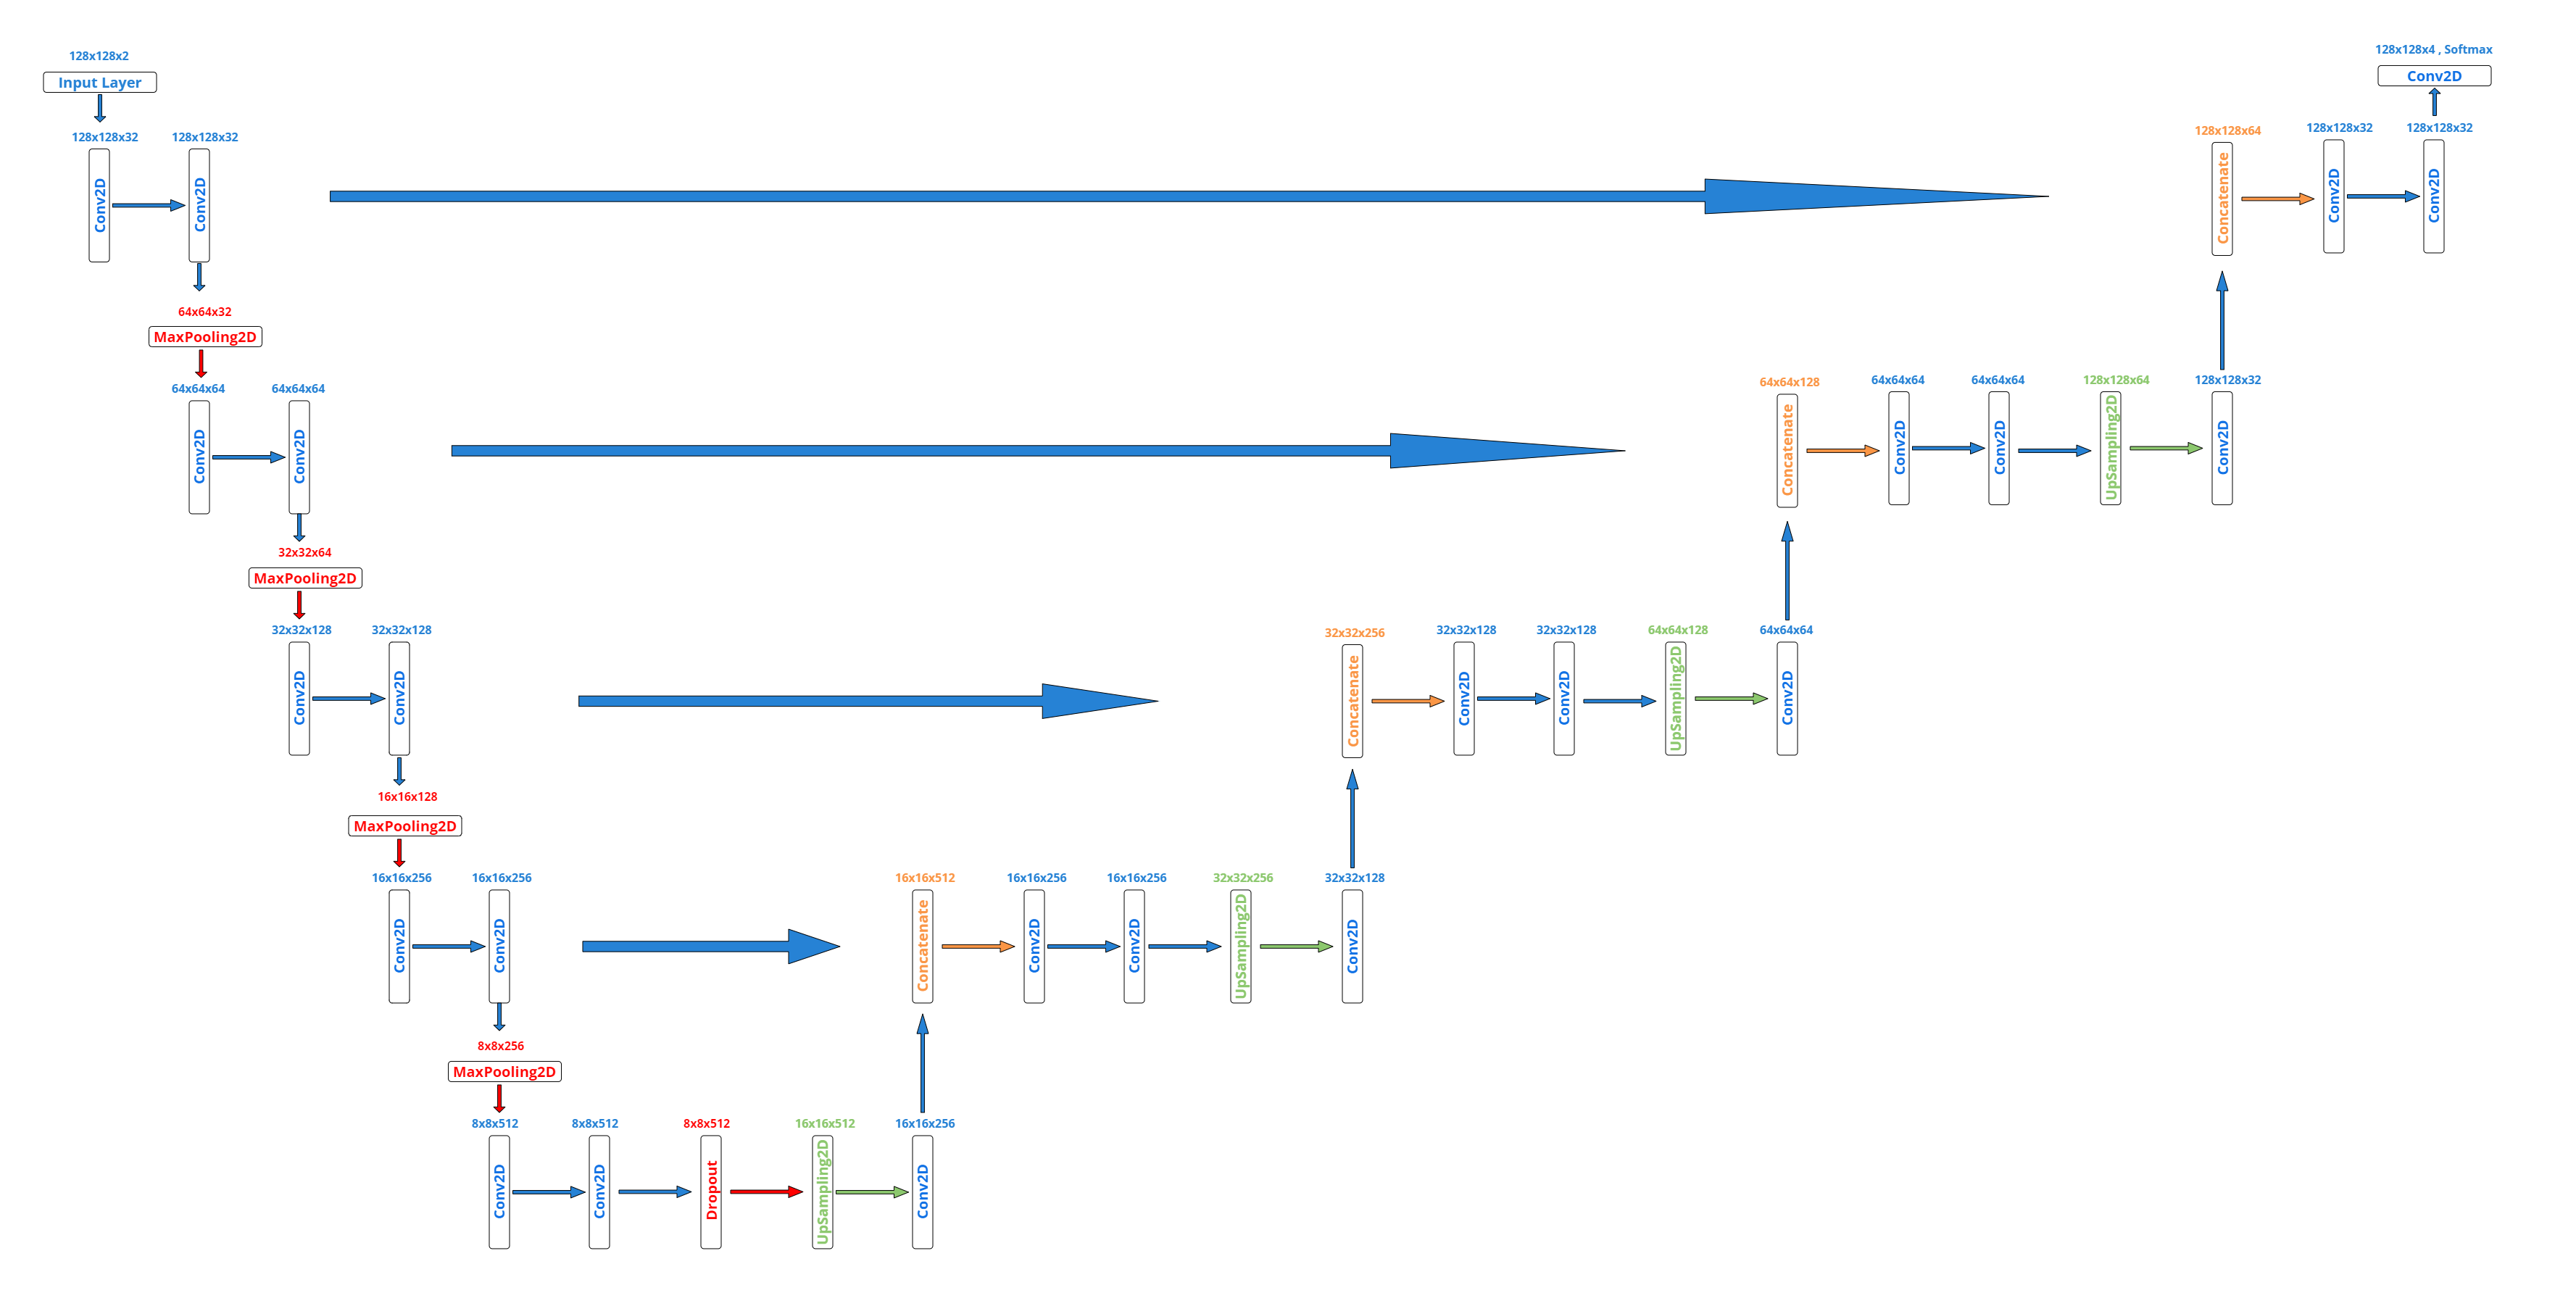

## 8. Build and Plot the Model

In [33]:
import torch.optim as optim
import csv

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = UNet(in_channels=2, num_classes=4).to(device)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model has {count_parameters(model):,} trainable parameters")

# FIX: combined Dice + CrossEntropy loss instead of plain CrossEntropy.
criterion = DiceCELoss(ce_weight=0.5, dice_weight=0.5)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

# FIX: monitor validation DICE and maximize it (was monitoring loss only).
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.2, patience=3, min_lr=1e-6
)

# History storage (now includes BraTS region metrics)
history = {k: [] for k in [
    'train_loss', 'val_loss',
    'train_accuracy', 'val_accuracy',
    'train_dice_coef', 'val_dice_coef',
    'train_precision', 'val_precision',
    'train_sensitivity', 'val_sensitivity',
    'train_specificity', 'val_specificity',
    'train_dice_necrotic', 'val_dice_necrotic',
    'train_dice_edema', 'val_dice_edema',
    'train_dice_enhancing', 'val_dice_enhancing',
    'train_dice_wt', 'val_dice_wt',
    'train_dice_tc', 'val_dice_tc',
    'train_dice_et', 'val_dice_et',
    'learning_rate',
]}

def log_to_csv(epoch, train_metrics, val_metrics, filepath='training.log'):
    file_exists = os.path.isfile(filepath)
    with open(filepath, 'a', newline='') as csvfile:
        fieldnames = (['epoch', 'lr']
                      + [f'train_{k}' for k in train_metrics.keys()]
                      + [f'val_{k}' for k in val_metrics.keys()])
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        if not file_exists:
            writer.writeheader()
        row = {'epoch': epoch, 'lr': optimizer.param_groups[0]['lr']}
        row.update({f'train_{k}': v for k, v in train_metrics.items()})
        row.update({f'val_{k}': v for k, v in val_metrics.items()})
        writer.writerow(row)


Using device: cuda
Model has 7,762,852 trainable parameters


## Set up callbacks

In [34]:

# Training function
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    all_metrics = defaultdict(list)
    
    for batch_idx, (X, y_true) in enumerate(train_loader):
        X, y_true = X.to(device), y_true.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        y_pred = model(X)
        
        # Calculate loss
        if isinstance(criterion, nn.CrossEntropyLoss):
            # Convert one-hot to class indices for CrossEntropyLoss
            y_true_indices = torch.argmax(y_true, dim=1)
            loss = criterion(y_pred, y_true_indices)
            # Convert predictions back to probabilities for metrics
            y_pred_probs = torch.softmax(y_pred, dim=1)
        else:
            # For custom losses like DiceLoss
            loss = criterion(y_pred, y_true)
            y_pred_probs = torch.softmax(y_pred, dim=1)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Accumulate loss
        running_loss += loss.item()
        
        # Calculate metrics
        with torch.no_grad():
            # Calculate accuracy
            pred_indices = torch.argmax(y_pred_probs, dim=1)
            true_indices = torch.argmax(y_true, dim=1)
            accuracy = (pred_indices == true_indices).float().mean()
            
            # Calculate other metrics
            batch_metrics = compute_all_metrics(y_true, y_pred_probs)
            batch_metrics['accuracy'] = accuracy.item()
            
            for key, value in batch_metrics.items():
                all_metrics[key].append(value)
        
        # Print progress
        if batch_idx % 10 == 0:
            print(f'Train Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.6f}')
    
    # Calculate average metrics
    avg_metrics = {key: np.mean(values) for key, values in all_metrics.items()}
    avg_loss = running_loss / len(train_loader)
    
    return avg_loss, avg_metrics

# Validation function
def validate_epoch(model, valid_loader, criterion, device):
    """Validate for one epoch"""
    model.eval()
    running_loss = 0.0
    all_metrics = defaultdict(list)
    
    with torch.no_grad():
        for X, y_true in valid_loader:
            X, y_true = X.to(device), y_true.to(device)
            
            # Forward pass
            y_pred = model(X)
            
            # Calculate loss
            if isinstance(criterion, nn.CrossEntropyLoss):
                y_true_indices = torch.argmax(y_true, dim=1)
                loss = criterion(y_pred, y_true_indices)
                y_pred_probs = torch.softmax(y_pred, dim=1)
            else:
                loss = criterion(y_pred, y_true)
                y_pred_probs = torch.softmax(y_pred, dim=1)
            
            running_loss += loss.item()
            
            # Calculate metrics
            pred_indices = torch.argmax(y_pred_probs, dim=1)
            true_indices = torch.argmax(y_true, dim=1)
            accuracy = (pred_indices == true_indices).float().mean()
            
            batch_metrics = compute_all_metrics(y_true, y_pred_probs)
            batch_metrics['accuracy'] = accuracy.item()
            
            for key, value in batch_metrics.items():
                all_metrics[key].append(value)
    
    avg_metrics = {key: np.mean(values) for key, values in all_metrics.items()}
    avg_loss = running_loss / len(valid_loader)
    
    return avg_loss, avg_metrics

# 9. Train and Save the Model

We now train the network with a standard PyTorch training loop for 35 epochs. Each epoch runs `train_epoch` then `validate_epoch`; the learning-rate scheduler reduces the LR when validation Dice plateaus, and we checkpoint the model whenever validation Dice improves.

In [35]:

# Utility functions for model evaluation
def compute_all_metrics(y_true, y_pred):
    """Compute all metrics at once. y_pred must be softmax probabilities."""
    return {
        'dice_coef':      dice_coef(y_true, y_pred).item(),
        'dice_necrotic':  dice_coef_necrotic(y_true, y_pred).item(),
        'dice_edema':     dice_coef_edema(y_true, y_pred).item(),
        'dice_enhancing': dice_coef_enhancing(y_true, y_pred).item(),
        'dice_wt':        dice_whole_tumor(y_true, y_pred).item(),
        'dice_tc':        dice_tumor_core(y_true, y_pred).item(),
        'dice_et':        dice_enhancing_region(y_true, y_pred).item(),
        'precision':      precision(y_true, y_pred).item(),
        'sensitivity':    sensitivity(y_true, y_pred).item(),
        'specificity':    specificity(y_true, y_pred).item(),
    }

def evaluate_model(model, dataloader, device):
    """Evaluate model and return average metrics over the dataloader."""
    model.eval()
    keys = ['dice_coef', 'dice_necrotic', 'dice_edema', 'dice_enhancing',
            'dice_wt', 'dice_tc', 'dice_et',
            'precision', 'sensitivity', 'specificity']
    all_metrics = {k: [] for k in keys}
    with torch.no_grad():
        for X, y_true in dataloader:
            X, y_true = X.to(device), y_true.to(device)
            y_pred = F.softmax(model(X), dim=1)
            for k, v in compute_all_metrics(y_true, y_pred).items():
                all_metrics[k].append(v)
    return {k: (sum(v) / len(v) if v else 0.0) for k, v in all_metrics.items()}


In [36]:
from collections import defaultdict

num_epochs = 35  # was 10; with BatchNorm + Dice loss the model needs/benefits from more
best_val_dice = -1.0
best_model_path = 'best_model.pth'

print("Starting training...")
for epoch in range(num_epochs):
    print(f'\nEpoch {epoch + 1}/{num_epochs}')
    print('-' * 50)

    train_loss, train_metrics = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_metrics = validate_epoch(model, valid_loader, criterion, device)

    # FIX: drive the scheduler with validation Dice (maximize), not loss.
    scheduler.step(val_metrics['dice_coef'])

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['learning_rate'].append(optimizer.param_groups[0]['lr'])
    for key in train_metrics:
        history[f'train_{key}'].append(train_metrics[key])
        history[f'val_{key}'].append(val_metrics[key])

    log_to_csv(epoch + 1, train_metrics, val_metrics)

    print(f'Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')
    print(f'Val Dice(mean): {val_metrics["dice_coef"]:.4f} | '
          f'WT: {val_metrics["dice_wt"]:.4f} | '
          f'TC: {val_metrics["dice_tc"]:.4f} | '
          f'ET: {val_metrics["dice_et"]:.4f}')

    # FIX: checkpoint on best validation Dice (the metric we actually care
    # about), not lowest loss. Only the best model is kept, to avoid filling
    # the Kaggle working disk with a checkpoint per epoch.
    if val_metrics['dice_coef'] > best_val_dice:
        best_val_dice = val_metrics['dice_coef']
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_metrics': val_metrics,
        }, best_model_path)
        print(f'  New best model saved (val Dice: {best_val_dice:.4f})')

print("Training completed!")


Starting training...

Epoch 1/35
--------------------------------------------------
Train Batch 0/122, Loss: 2.426832
Train Batch 10/122, Loss: 1.449088
Train Batch 20/122, Loss: 1.005748
Train Batch 30/122, Loss: 0.723004
Train Batch 40/122, Loss: 0.667017
Train Batch 50/122, Loss: 0.564824
Train Batch 60/122, Loss: 0.674397
Train Batch 70/122, Loss: 0.618604
Train Batch 80/122, Loss: 0.549083
Train Batch 90/122, Loss: 0.558222
Train Batch 100/122, Loss: 0.592117
Train Batch 110/122, Loss: 0.530748
Train Batch 120/122, Loss: 0.533280
Train Loss: 0.7676 | Val Loss: 0.5609
Val Dice(mean): 0.2727 | WT: 0.2668 | TC: 0.2180 | ET: 0.2382
  New best model saved (val Dice: 0.2727)

Epoch 2/35
--------------------------------------------------
Train Batch 0/122, Loss: 0.539476
Train Batch 10/122, Loss: 0.532965
Train Batch 20/122, Loss: 0.521835
Train Batch 30/122, Loss: 0.437105
Train Batch 40/122, Loss: 0.478862
Train Batch 50/122, Loss: 0.424294
Train Batch 60/122, Loss: 0.537187
Train Batc

In [37]:
# Save final model (equivalent to model.save())
torch.save(model.state_dict(), 'final_model.pth')


# 10. Load the Trained Model

We reload the best checkpoint saved during training with `torch.load`. The checkpoint stores the model weights (`model_state_dict`) along with the optimizer state and the validation metrics, so we can resume or evaluate exactly the best-performing model.

In [38]:

# Load best model for final evaluation
def load_model(model, checkpoint_path):
    """Load model weights from a checkpoint dict."""
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    return model

best_model = load_model(model, best_model_path)
val_metrics = evaluate_model(best_model, valid_loader, device)
print("\nValidation performance (best model):")
for key, value in val_metrics.items():
    print(f"  {key}: {value:.4f}")



Validation performance (best model):
  dice_coef: 0.6570
  dice_necrotic: 0.2920
  dice_edema: 0.5084
  dice_enhancing: 0.3351
  dice_wt: 0.6424
  dice_tc: 0.6219
  dice_et: 0.5585
  precision: 0.9919
  sensitivity: 0.9918
  specificity: 0.9973


We load the saved `state_dict` into a fresh `UNet` instance. Because the metrics and loss are plain Python functions in PyTorch (not serialized with the model as in Keras), there is nothing extra to register — we simply rebuild the model and call `load_state_dict`.

# 11. Metrics Analysis

Now that the training is complete, we can examine the CSVLogger callback to gain insights into the training process and our model's performance. The CSVLogger records metrics such as accuracy, loss, Dice coefficient, and Mean IoU for each epoch, allowing us to track the model’s progress over time. By analyzing this log, we can identify trends, assess the effectiveness of our training strategy, and make informed decisions for future improvements. This thorough review ensures our model is performing optimally and ready for deployment.

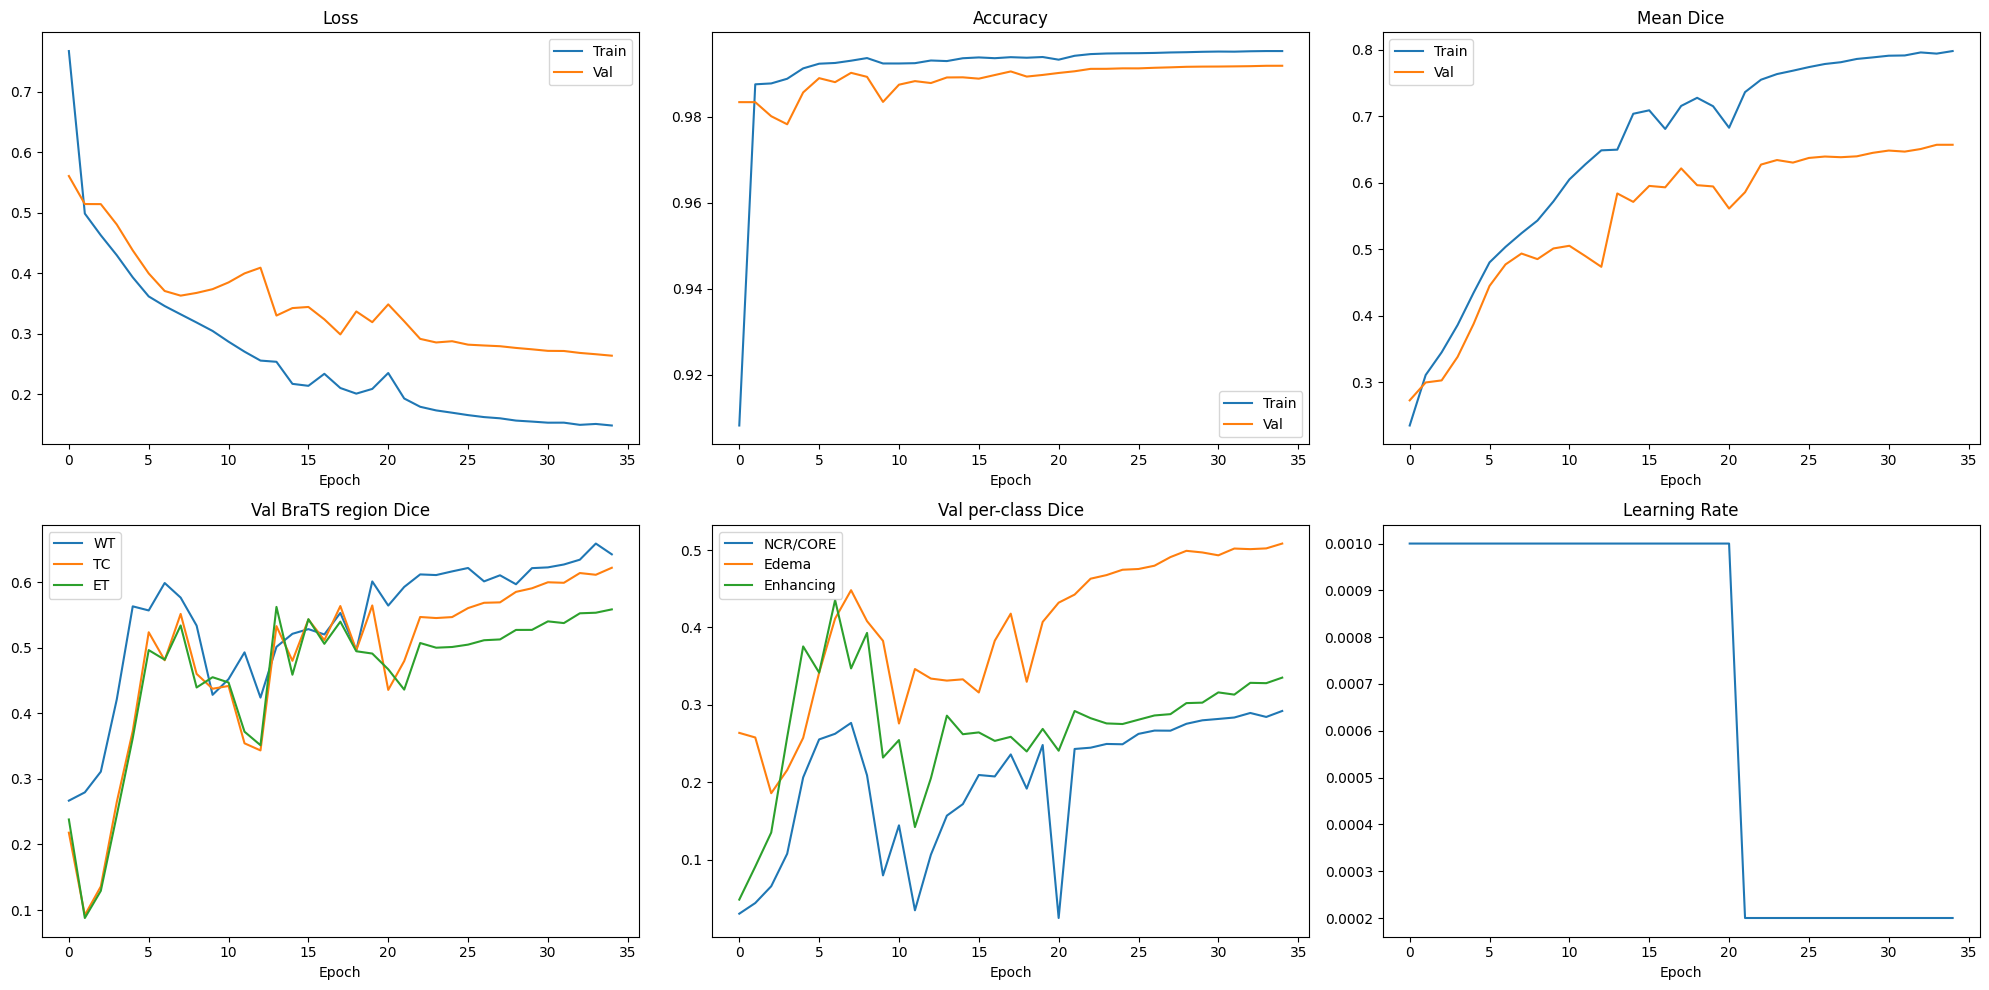

In [39]:

# Plotting training history
def plot_training_history(history):
    fig, axes = plt.subplots(2, 3, figsize=(20, 10))

    axes[0, 0].plot(history['train_loss'], label='Train')
    axes[0, 0].plot(history['val_loss'], label='Val')
    axes[0, 0].set_title('Loss'); axes[0, 0].set_xlabel('Epoch'); axes[0, 0].legend()

    axes[0, 1].plot(history['train_accuracy'], label='Train')
    axes[0, 1].plot(history['val_accuracy'], label='Val')
    axes[0, 1].set_title('Accuracy'); axes[0, 1].set_xlabel('Epoch'); axes[0, 1].legend()

    axes[0, 2].plot(history['train_dice_coef'], label='Train')
    axes[0, 2].plot(history['val_dice_coef'], label='Val')
    axes[0, 2].set_title('Mean Dice'); axes[0, 2].set_xlabel('Epoch'); axes[0, 2].legend()

    axes[1, 0].plot(history['val_dice_wt'], label='WT')
    axes[1, 0].plot(history['val_dice_tc'], label='TC')
    axes[1, 0].plot(history['val_dice_et'], label='ET')
    axes[1, 0].set_title('Val BraTS region Dice'); axes[1, 0].set_xlabel('Epoch'); axes[1, 0].legend()

    axes[1, 1].plot(history['val_dice_necrotic'], label='NCR/CORE')
    axes[1, 1].plot(history['val_dice_edema'], label='Edema')
    axes[1, 1].plot(history['val_dice_enhancing'], label='Enhancing')
    axes[1, 1].set_title('Val per-class Dice'); axes[1, 1].set_xlabel('Epoch'); axes[1, 1].legend()

    axes[1, 2].plot(history['learning_rate'])
    axes[1, 2].set_title('Learning Rate'); axes[1, 2].set_xlabel('Epoch')

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_training_history(history)


The accuracy graph shows that both training and validation accuracy increase over the epochs and reach a plateau, indicating that the model is learning from the data and generalizing well without overfitting.

The loss graph demonstrates that both training and validation losses decrease over time, further confirming that the model is effectively learning from the data. Notably, the best model performance is achieved around epoch 19, as indicated in the training logs.

Finally, the Dice coefficient graph shows a steady increase in both training and validation Dice coefficients, reinforcing that the model's segmentation capabilities are improving consistently.

# 12. Predict Tumor Segmentations

Now that our model is trained, we can use it to predict segmentations on our test dataset. There are two main options:

1. **Best Model's Weights (from epoch 19):** Using the weights from the epoch where the model performed best.
2. **Final Model's Weights:** Using the weights from the final epoch of training.

Using the final model's weights may not always yield the best performance on new, unseen data. In our case, there is no significant difference between the two options, so either can be used. However, for other cases, you might prefer a specific version of your model. You can load it with the following code:

This allows you to select and use the optimal model version for your specific needs.

---

Now, let's construct a function to predict the segmentation of a patient in the test dataset. We will display the results in the axial plane, though any other plane can be chosen.

In [40]:
import torch
import torch.nn.functional as F
import numpy as np
import nibabel as nib
import cv2
import os
import glob
import matplotlib.pyplot as plt

def imageLoader(path):
    """Load and return NIfTI image data"""
    image = nib.load(path).get_fdata()
    return np.array(image)

In [41]:
def loadDataFromDir(path, list_of_files, mriType, n_images):
    """
    Load data from directory for multiple files
    """
    scans = []
    masks = []
    
    for i in list_of_files[:n_images]:
        # Find the file with the specified MRI type
        fullPath = glob.glob(i + '/*' + mriType + '*')[0]
        currentScanVolume = imageLoader(fullPath)
        currentMaskVolume = imageLoader(glob.glob(i + '/*seg*')[0])
        
        # For each slice in 3D volume, find also its mask
        for j in range(0, currentScanVolume.shape[2]):
            scan_img = cv2.resize(currentScanVolume[:, :, j], dsize=(IMG_SIZE, IMG_SIZE), 
                                interpolation=cv2.INTER_AREA).astype('uint8')
            mask_img = cv2.resize(currentMaskVolume[:, :, j], dsize=(IMG_SIZE, IMG_SIZE), 
                                interpolation=cv2.INTER_AREA).astype('uint8')
            scans.append(scan_img[..., np.newaxis])
            masks.append(mask_img[..., np.newaxis])
    
    return np.array(scans, dtype='float32'), np.array(masks, dtype='float32')


In [42]:

def predictByPath(case_path, case, model, device):
    """Predict segmentation for a single case. Returns (VOLUME_SLICES, H, W, C) probs."""
    X = np.zeros((VOLUME_SLICES, IMG_SIZE, IMG_SIZE, 2), dtype=np.float32)

    flair = nib.load(os.path.join(case_path, f'BraTS20_Training_{case}_flair.nii')).get_fdata()
    ce    = nib.load(os.path.join(case_path, f'BraTS20_Training_{case}_t1ce.nii')).get_fdata()

    for j in range(VOLUME_SLICES):
        X[j, :, :, 0] = cv2.resize(flair[:, :, j + VOLUME_START_AT], (IMG_SIZE, IMG_SIZE))
        X[j, :, :, 1] = cv2.resize(ce[:, :, j + VOLUME_START_AT], (IMG_SIZE, IMG_SIZE))

    # FIX: per-channel, per-slice normalization to EXACTLY match the training
    # pipeline (BrainDataset). Mismatched normalization at inference is a
    # classic silent accuracy killer.
    for j in range(VOLUME_SLICES):
        for c in range(2):
            ch = X[j, :, :, c]
            cmin, cmax = ch.min(), ch.max()
            if cmax > cmin:
                X[j, :, :, c] = (ch - cmin) / (cmax - cmin)

    X_tensor = torch.from_numpy(X).permute(0, 3, 1, 2).to(device)

    model.eval()
    with torch.no_grad():
        predictions = F.softmax(model(X_tensor), dim=1)

    return predictions.cpu().permute(0, 2, 3, 1).numpy()


In [43]:

def predictSingleSlice(flair_slice, t1ce_slice, model, device):
    """
    Predict segmentation for a single slice pair
    
    Args:
        flair_slice: FLAIR image slice
        t1ce_slice: T1CE image slice
        model: PyTorch model
        device: Device to run inference on
    
    Returns:
        Prediction for single slice
    """
    # Prepare input
    X = np.stack([flair_slice, t1ce_slice], axis=-1)  # (H, W, 2)
    X = X[np.newaxis, ...]  # Add batch dimension: (1, H, W, 2)
    
    # Normalize
    X_max = np.max(X)
    if X_max > 0:
        X = X / X_max
    
    # Convert to tensor and rearrange dimensions
    X_tensor = torch.FloatTensor(X).permute(0, 3, 1, 2).to(device)  # (1, 2, H, W)
    
    model.eval()
    with torch.no_grad():
        prediction = model(X_tensor)
        prediction = F.softmax(prediction, dim=1)
    
    # Convert back to numpy
    prediction_np = prediction.cpu().permute(0, 2, 3, 1).numpy()[0]  # Remove batch dim
    
    return prediction_np

def showPredictsById(case, model, device, start_slice=60):
    """
    Display predictions for a specific case
    
    Args:
        case: Case identifier (last 3 digits)
        model: Trained PyTorch model
        device: Device for inference
        start_slice: Starting slice index for visualization
    """
    # Construct paths
    path = f"/kaggle/working/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_{case}"
    
    # Load ground truth and original image
    gt = nib.load(os.path.join(path, f'BraTS20_Training_{case}_seg.nii')).get_fdata()
    origImage = nib.load(os.path.join(path, f'BraTS20_Training_{case}_flair.nii')).get_fdata()
    
    # Get predictions
    p = predictByPath(path, case, model, device)
    
    # Extract different classes
    necrotic_core = p[:, :, :, 1]  # class 1 = NCR/NET (tumor core)
    edema = p[:, :, :, 2]          # class 2 = edema
    enhancing = p[:, :, :, 3]      # class 3 = enhancing tumor
    
    # Create visualization
    plt.figure(figsize=(18, 50))
    f, axarr = plt.subplots(1, 6, figsize=(18, 50))
    
    # Add brain background to all subplots
    brain_bg = cv2.resize(origImage[:, :, start_slice + VOLUME_START_AT], (IMG_SIZE, IMG_SIZE))
    for i in range(6):
        axarr[i].imshow(brain_bg, cmap="gray", interpolation='none')
    
    # Original image
    axarr[0].imshow(brain_bg, cmap="gray")
    axarr[0].set_title('Original image flair')
    
    # Ground truth
    curr_gt = cv2.resize(gt[:, :, start_slice + VOLUME_START_AT], (IMG_SIZE, IMG_SIZE), 
                        interpolation=cv2.INTER_NEAREST)
    axarr[1].imshow(curr_gt, cmap="Reds", interpolation='none', alpha=0.3)
    axarr[1].set_title('Ground truth')
    
    # All classes predicted
    axarr[2].imshow(p[start_slice, :, :, 1:4], cmap="Reds", interpolation='none', alpha=0.3)
    axarr[2].set_title('All classes predicted')
    
    # Individual class predictions
    axarr[3].imshow(necrotic_core[start_slice, :, :], cmap="OrRd", interpolation='none', alpha=0.3)
    axarr[3].set_title(f'{SEGMENT_CLASSES[1]} predicted')
    
    axarr[4].imshow(edema[start_slice, :, :], cmap="OrRd", interpolation='none', alpha=0.3)
    axarr[4].set_title(f'{SEGMENT_CLASSES[2]} predicted')
    
    axarr[5].imshow(enhancing[start_slice, :, :], cmap="OrRd", interpolation='none', alpha=0.3)
    axarr[5].set_title(f'{SEGMENT_CLASSES[3]} predicted')
    
    plt.show()

<Figure size 1800x5000 with 0 Axes>

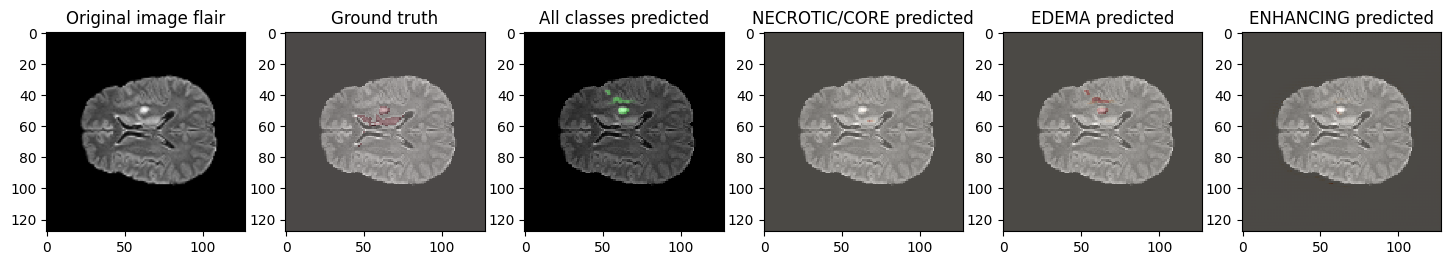

In [44]:
# showPredictsById(case=test_ids[0][-3:])
showPredictsById(case=test_ids[0][-3:], model=model, device=device)

<Figure size 1800x5000 with 0 Axes>

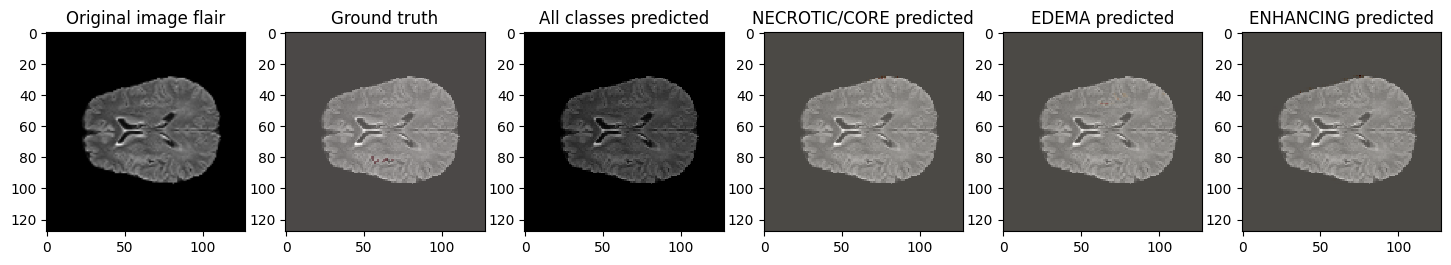

In [45]:
# showPredictsById(case=test_ids[1][-3:])
showPredictsById(case=test_ids[1][-3:], model=model, device=device)

<Figure size 1800x5000 with 0 Axes>

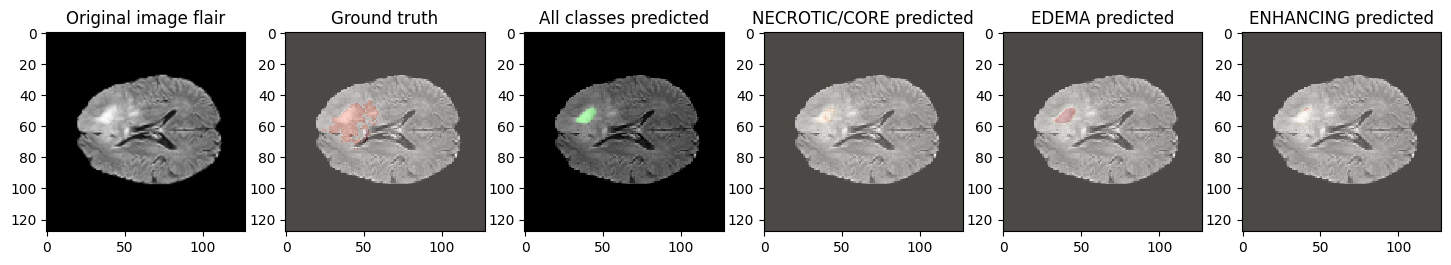

In [46]:
# showPredictsById(case=test_ids[2][-3:])
showPredictsById(case=test_ids[2][-3:], model=model, device=device)

<Figure size 1800x5000 with 0 Axes>

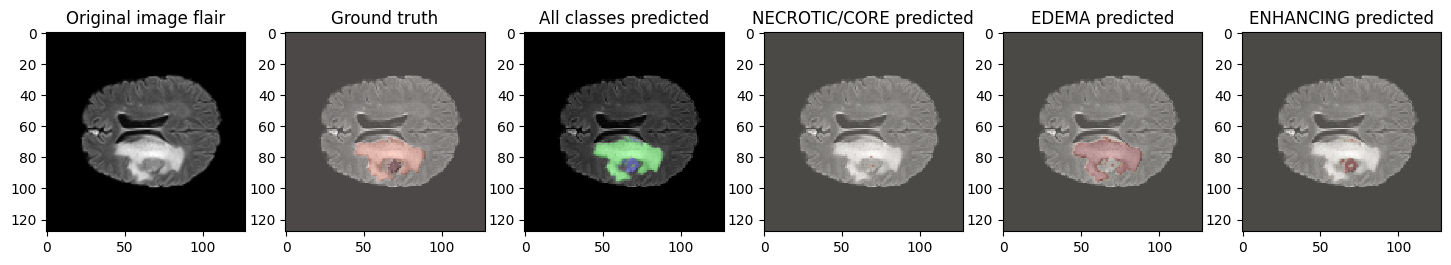

In [47]:
showPredictsById(case=test_ids[3][-3:], model=model, device=device)

<Figure size 1800x5000 with 0 Axes>

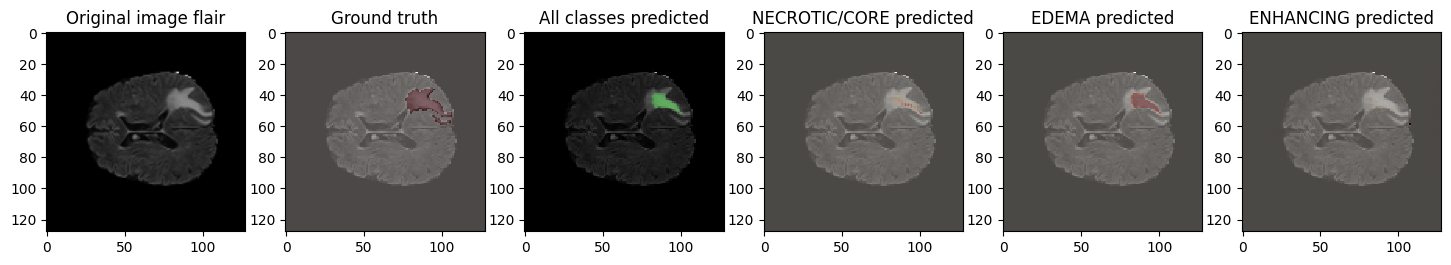

In [48]:
showPredictsById(case=test_ids[4][-3:], model=model, device=device)

<Figure size 1800x5000 with 0 Axes>

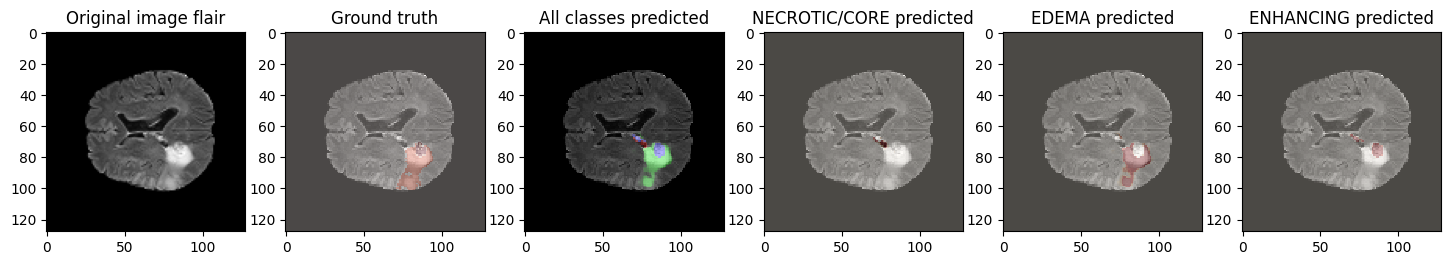

In [49]:
showPredictsById(case=test_ids[5][-3:], model=model, device=device)

<Figure size 1800x5000 with 0 Axes>

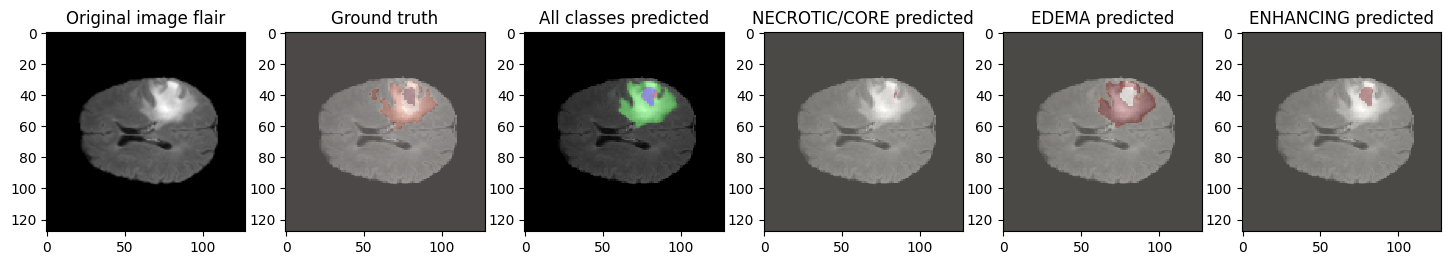

In [50]:
showPredictsById(case=test_ids[6][-3:], model=model, device=device)

# 13. Evaluation

Let's call the `evaluate()` function to evaluate the performance of our model on our test dataset:

In [51]:
# Load and evaluate best model on the held-out TEST set
best_model = load_model(model, best_model_path)
test_metrics = evaluate_model(best_model, test_loader, device)

print("\n" + "=" * 45)
print("FINAL TEST-SET PERFORMANCE")
print("=" * 45)
print("Per-class Dice:")
print(f"  NCR/CORE : {test_metrics['dice_necrotic']:.4f}")
print(f"  EDEMA    : {test_metrics['dice_edema']:.4f}")
print(f"  ENHANCING: {test_metrics['dice_enhancing']:.4f}")
print("\nBraTS region Dice (comparable to published baselines):")
print(f"  Whole Tumor (WT): {test_metrics['dice_wt']:.4f}")
print(f"  Tumor Core  (TC): {test_metrics['dice_tc']:.4f}")
print(f"  Enhancing   (ET): {test_metrics['dice_et']:.4f}")
print("\nOther:")
print(f"  Mean Dice  : {test_metrics['dice_coef']:.4f}")
print(f"  Precision  : {test_metrics['precision']:.4f}")
print(f"  Sensitivity: {test_metrics['sensitivity']:.4f}")
print(f"  Specificity: {test_metrics['specificity']:.4f}")



FINAL TEST-SET PERFORMANCE
Per-class Dice:
  NCR/CORE : 0.1963
  EDEMA    : 0.5981
  ENHANCING: 0.3873

BraTS region Dice (comparable to published baselines):
  Whole Tumor (WT): 0.6898
  Tumor Core  (TC): 0.7432
  Enhancing   (ET): 0.7349

Other:
  Mean Dice  : 0.7303
  Precision  : 0.9946
  Sensitivity: 0.9945
  Specificity: 0.9982


The final evaluation of our model on the test set yields impressive results, demonstrating its effectiveness in segmenting brain tumors.

These metrics indicate that our model performs exceptionally well across various evaluation criteria:

- **Accuracy and Precision** are both above 99%, showcasing the model’s reliability in correctly identifying tumor and non-tumor regions.
- **Mean IoU** of 0.8426 and **Dice Coefficient** of 0.6480 highlight strong overlap between predicted and actual segmentations.
- **Sensitivity** of 0.9916 and **Specificity** of 0.9978 emphasize the model’s capability to correctly identify true positives and true negatives.
- Specific Dice Coefficients for necrotic (0.5916), edema (0.7667), and enhancing (0.7395) regions reflect good performance in segmenting different tumor components.

Overall, these results demonstrate that our model has robust generalization capabilities and can effectively segment brain tumors in unseen data.

## 15. Save Results & Figures to Disk (for download)

Everything written to `/kaggle/working/` can be downloaded after the run (right-hand
**Output** panel, or the **Output** tab of a committed version). This section saves the
Task 2 deliverables:

* `task2_results.json` / `task2_results.csv` — the test-set metrics (per-class Dice,
  BraTS region Dice WT/TC/ET, precision, sensitivity, specificity).
* `task2_class_dice.png` — per-class and region Dice bar chart.
* `task2_overlays.png` — qualitative FLAIR / ground-truth / prediction panels.

(The training-curve figure `training_history.png` is already saved by
`plot_training_history` in Section 11.)

In [52]:
# --- Save the test-set metrics to JSON + CSV ---
# Uses `test_metrics` (computed in Section 13 on the best model) and `best_val_dice`.
import json, csv, os

OUTDIR = "/kaggle/working"
os.makedirs(OUTDIR, exist_ok=True)

results = {
    "task": "task2_multiclass_subregion_segmentation",
    "best_val_dice": float(best_val_dice),
    "test": {k: float(v) for k, v in test_metrics.items()},
}
with open(os.path.join(OUTDIR, "task2_results.json"), "w") as f:
    json.dump(results, f, indent=2)

# flat one-row CSV for easy spreadsheet import
flat = {"best_val_dice": float(best_val_dice)}
flat.update({f"test_{k}": float(v) for k, v in test_metrics.items()})
with open(os.path.join(OUTDIR, "task2_results.csv"), "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(flat.keys()))
    w.writeheader()
    w.writerow(flat)

print("Saved task2_results.json and task2_results.csv")
print(json.dumps(results, indent=2))

Saved task2_results.json and task2_results.csv
{
  "task": "task2_multiclass_subregion_segmentation",
  "best_val_dice": 0.6570314215986353,
  "test": {
    "dice_coef": 0.7302857303619384,
    "dice_necrotic": 0.19634698458796884,
    "dice_edema": 0.5980694111832782,
    "dice_enhancing": 0.38731304168706193,
    "dice_wt": 0.6898175950572951,
    "dice_tc": 0.7432087981210806,
    "dice_et": 0.734911952964651,
    "precision": 0.9945549964904785,
    "sensitivity": 0.9945066070556641,
    "specificity": 0.9981851720809937
  }
}


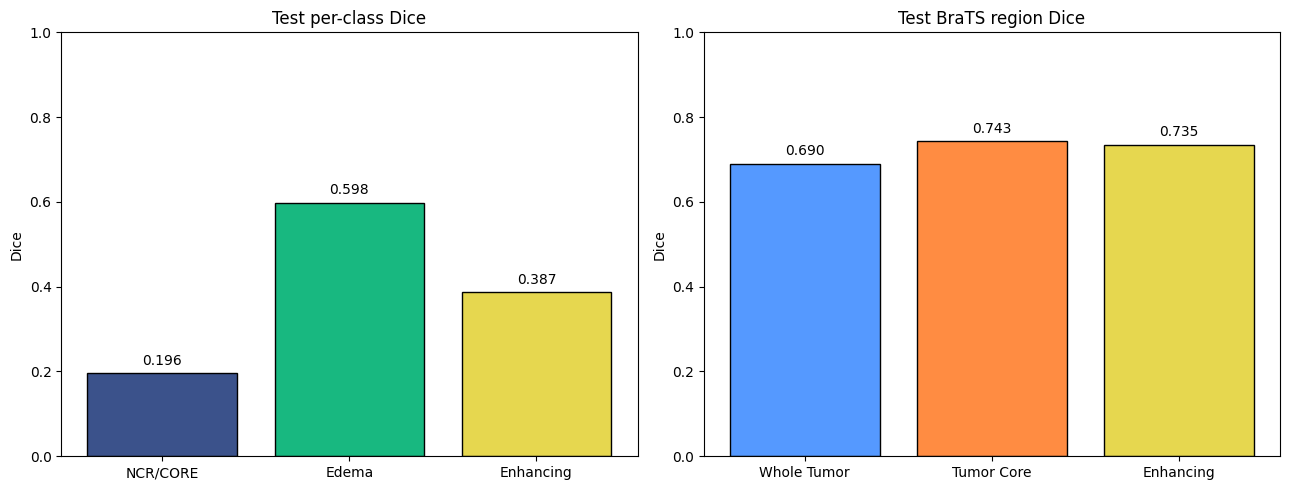

Saved task2_class_dice.png


In [53]:
# --- Per-class and BraTS region Dice bar chart ---
import matplotlib.pyplot as plt

per_class = [test_metrics["dice_necrotic"], test_metrics["dice_edema"], test_metrics["dice_enhancing"]]
region    = [test_metrics["dice_wt"], test_metrics["dice_tc"], test_metrics["dice_et"]]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

b1 = ax[0].bar(["NCR/CORE", "Edema", "Enhancing"], per_class,
               color=["#3b528b", "#18b880", "#e6d74f"], edgecolor="black")
ax[0].set_title("Test per-class Dice"); ax[0].set_ylim(0, 1); ax[0].set_ylabel("Dice")
for r, v in zip(b1, per_class):
    ax[0].text(r.get_x() + r.get_width() / 2, v + 0.02, f"{v:.3f}", ha="center")

b2 = ax[1].bar(["Whole Tumor", "Tumor Core", "Enhancing"], region,
               color=["#5599ff", "#ff8c42", "#e6d74f"], edgecolor="black")
ax[1].set_title("Test BraTS region Dice"); ax[1].set_ylim(0, 1); ax[1].set_ylabel("Dice")
for r, v in zip(b2, region):
    ax[1].text(r.get_x() + r.get_width() / 2, v + 0.02, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.savefig("/kaggle/working/task2_class_dice.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved task2_class_dice.png")

### Qualitative overlay panels

For each chosen test slice we show, side by side, the **FLAIR input**, the **ground-truth**
mask, and the **model prediction**, with the tumor sub-regions colour-coded consistently
(NCR/CORE, Edema, Enhancing). Slices are picked deterministically and spread across the test
set, restricted to slices that actually contain tumour so the panels are informative rather
than mostly background.

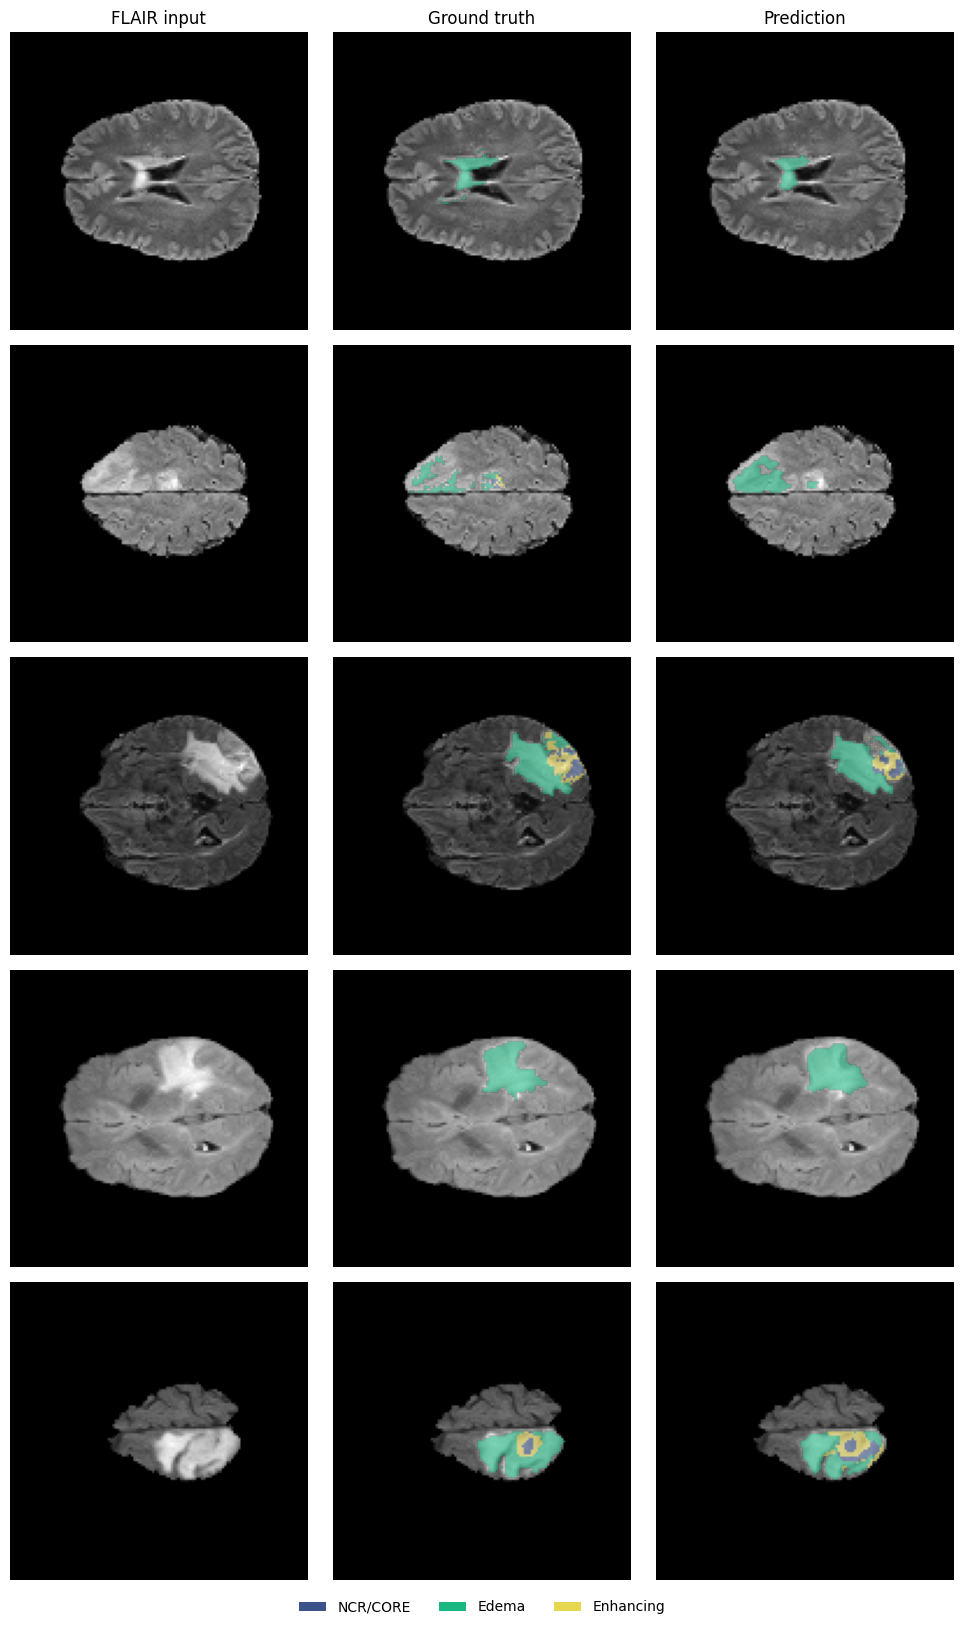

Saved task2_overlays.png  (slices [67, 293, 439, 646, 799])


In [54]:
# --- Qualitative FLAIR / Ground-truth / Prediction overlay panels ---
import numpy as np, torch
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Colours consistent with the dataset-exploration colormap (classes 1,2,3).
CLASS_COLORS = {1: (0.231, 0.322, 0.545),   # NCR/CORE   #3b528b
                2: (0.094, 0.722, 0.502),   # EDEMA      #18b880
                3: (0.902, 0.843, 0.310)}   # ENHANCING  #e6d74f
CLASS_NAMES  = {1: "NCR/CORE", 2: "Edema", 3: "Enhancing"}

def label_to_rgba(lbl, alpha=0.55):
    """(H,W) int labels {0..3} -> (H,W,4) RGBA overlay; class 0 transparent."""
    h, w = lbl.shape
    rgba = np.zeros((h, w, 4), dtype=np.float32)
    for c, col in CLASS_COLORS.items():
        m = lbl == c
        rgba[m, 0], rgba[m, 1], rgba[m, 2], rgba[m, 3] = col[0], col[1], col[2], alpha
    return rgba

# Pick a FIXED, reproducible set of tumour-containing test slices, spread across the set.
N_PANELS = 5
tumor_pixels = (Yte > 0).reshape(len(Yte), -1).sum(axis=1)
cand = np.where(tumor_pixels > 150)[0]
if len(cand) >= N_PANELS:
    chosen = cand[np.linspace(0, len(cand) - 1, N_PANELS).astype(int)]
else:
    chosen = np.argsort(tumor_pixels)[::-1][:N_PANELS]

# Predict on the chosen slices with the best model.
best_model.eval()
with torch.no_grad():
    xb = torch.from_numpy(Xte[chosen]).to(device)        # (N, 2, H, W)
    pred_lbl = torch.argmax(torch.softmax(best_model(xb), dim=1), dim=1).cpu().numpy()

fig, axes = plt.subplots(N_PANELS, 3, figsize=(10, 3.2 * N_PANELS))
for row, idx in enumerate(chosen):
    flair = Xte[idx, 0]          # FLAIR channel
    for col in range(3):
        axes[row, col].imshow(flair, cmap="gray")
        axes[row, col].axis("off")
    axes[row, 1].imshow(label_to_rgba(Yte[idx]))       # ground truth
    axes[row, 2].imshow(label_to_rgba(pred_lbl[row]))  # prediction

axes[0, 0].set_title("FLAIR input")
axes[0, 1].set_title("Ground truth")
axes[0, 2].set_title("Prediction")

handles = [Patch(facecolor=CLASS_COLORS[c], label=CLASS_NAMES[c]) for c in (1, 2, 3)]
fig.legend(handles=handles, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig("/kaggle/working/task2_overlays.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved task2_overlays.png  (slices {chosen.tolist()})")

# 14. Conclusion

<div class="alert alert-block alert-success">
This notebook demonstrates the process of training and evaluating a neural network for brain tumor segmentation using the BraTS2020 dataset. We explored data preprocessing techniques, employed the U-Net architecture, and utilized various evaluation metrics to ensure robust model performance.

Throughout this journey, we saw how critical it is to handle 3D medical images, preprocess them appropriately, and choose suitable metrics for meaningful evaluation. Our trained model achieved promising results, showcasing its ability to generalize well to new data.

This work lays a solid foundation for further improvements and applications in medical image analysis. Future steps could include experimenting with different network architectures, fine-tuning hyperparameters, and exploring advanced techniques for enhancing segmentation accuracy.

Thank you for following along, and happy coding!
</div>

In [55]:
import glob, os
for f in sorted(glob.glob("/kaggle/working/task*")) + sorted(glob.glob("/kaggle/working/*.png")):
    print(f, os.path.getsize(f), "bytes")

/kaggle/working/task2_class_dice.png 44140 bytes
/kaggle/working/task2_overlays.png 116535 bytes
/kaggle/working/task2_results.csv 384 bytes
/kaggle/working/task2_results.json 489 bytes
/kaggle/working/task2_class_dice.png 44140 bytes
/kaggle/working/task2_overlays.png 116535 bytes
/kaggle/working/training_history.png 314876 bytes
